In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from src.config import load_config
from src.data.factory import build_source
from src.data.schema import CreditoSchema
from src.features import cleaning, derive


# 1. Carga de datos

Los datos se leen a través del puerto `DataSource` configurado en `config/config.yaml`. Hoy el origen
es el CSV crudo; pasar a una base de datos en la nube es registrar un adaptador nuevo en
`src/data/factory.py`, sin tocar este notebook ni el resto del pipeline.

La preparación de la sección 2 vive en `src/features/` y el contrato de validación en
`src/data/schema.py`. El notebook documenta **por qué** se hace cada paso y los módulos lo ejecutan,
así el modelado consume exactamente los mismos datos que se analizan aquí.


In [2]:
fuente = build_source(load_config().data_source)

df = fuente.read()
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  object 
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null 

# 2. Exploración inicial de los datos

## 2.1 Descripción general y caracterización de los datos

No se entregó diccionario de datos, por lo que la semántica de cada variable se infiere del negocio
(originación de crédito de consumo en Colombia) y de la distribución observada de los valores.

La variable objetivo es **`Pago_atiempo`**: indica si el crédito se pagó a tiempo (`1`) o cayó en mora (`0`).

In [3]:
df.sample(5)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
10332,9,27/12/2024 16:32,1449436,10,53,Independiente,3100000,1580000,122934,"95,227787",987.0,6,0,0.0,3674.0,3674.0,NaN,1,0,3,NaN,NaN,1
538,9,6/06/2025 10:55,1414458,9,49,Independiente,3269000,1895400,132541,"95,227787",756.0,5,1,0.0,12832.0,8805.0,0.0,0,5,0,3094439.0,Creciente,1
4874,9,22/06/2025 12:05,1526746,9,43,Empleado,4500000,2500000,143131,"95,227787",846.0,7,2,0.0,93807.0,93807.0,0.0,4,0,2,2727272.0,Creciente,1
6118,4,10/05/2025 17:13,1021020,6,57,Empleado,1770000,600000,151796,"95,227787",822.0,7,1,0.0,4275.0,4275.0,0.0,4,0,2,NaN,NaN,1
2108,4,19/04/2025 17:38,1724880,24,55,Independiente,1200000,236000,76847,"95,227787",806.0,3,4,0.0,4033.0,3392.0,0.0,1,0,1,NaN,NaN,1


In [4]:
df.describe()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
std,2.338279,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668
min,4.000000,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000


### Caracterización de los datos

| Variable | Tipo | Escala / niveles | Lectura de negocio |
| --- | --- | --- | --- |
| `tipo_credito` | Categórico nominal politómico | 6 niveles (4, 6, 7, 9, 10, 68) | Línea o producto de crédito colocado |
| `fecha_prestamo` | Fecha-hora | Continua | Momento del desembolso |
| `capital_prestado` | Numérico continuo | Razón (COP) | Monto desembolsado |
| `plazo_meses` | Numérico discreto | Razón (meses) | Plazo pactado |
| `edad_cliente` | Numérico discreto | Razón (años) | Edad del titular |
| `tipo_laboral` | Categórico nominal **dicotómico** | Empleado / Independiente | Vínculo laboral declarado |
| `salario_cliente` | Numérico continuo | Razón (COP) | Ingreso **declarado** por el cliente |
| `total_otros_prestamos` | Numérico continuo | Razón (COP) | Endeudamiento con otras entidades |
| `cuota_pactada` | Numérico continuo | Razón (COP) | Cuota mensual del crédito |
| `puntaje` | Numérico continuo | Intervalo (0–95.23) | Score interno. **Sospecha de fuga**, ver 2.3 |
| `puntaje_datacredito` | Numérico discreto | Intervalo (150–950) | Score de buró (DataCrédito) |
| `cant_creditosvigentes` | Numérico discreto | Razón (conteo) | Créditos vigentes del cliente |
| `huella_consulta` | Numérico discreto | Razón (conteo) | Consultas recientes al buró |
| `saldo_mora` | Numérico continuo | Razón | Saldo en mora reportado en buró |
| `saldo_total` | Numérico continuo | Razón | Saldo total reportado en buró |
| `saldo_principal` | Numérico continuo | Razón | Saldo capital reportado en buró |
| `saldo_mora_codeudor` | Numérico continuo | Razón | Mora del codeudor. Casi constante, ver 2.3 |
| `creditos_sectorFinanciero` | Numérico discreto | Razón (conteo) | Obligaciones en sector financiero |
| `creditos_sectorCooperativo` | Numérico discreto | Razón (conteo) | Obligaciones en sector cooperativo |
| `creditos_sectorReal` | Numérico discreto | Razón (conteo) | Obligaciones en sector real |
| `promedio_ingresos_datacredito` | Numérico continuo | Razón (COP) | Ingreso **estimado por el buró** |
| `tendencia_ingresos` | Categórico **ordinal** politómico | Decreciente < Estable < Creciente | Evolución del ingreso según buró |
| `Pago_atiempo` | Categórico **dicotómico** (booleano) | 0 / 1 | **Variable objetivo** |

Se dispone de dos fuentes de ingreso que conviene contrastar: la **declarada** (`salario_cliente`)
y la **estimada por el buró** (`promedio_ingresos_datacredito`). La discrepancia entre ambas se
explota como variable derivada en 2.6.

In [5]:
print(f'Registros: {len(df):,} | Variables: {df.shape[1]} | Duplicados exactos: {df.duplicated().sum()}')
print(f'Tasa de incumplimiento: {(1 - df["Pago_atiempo"].mean()):.2%}')

resumen = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(),
})
resumen.sort_values('pct_nulos', ascending=False)

Registros: 10,763 | Variables: 23 | Duplicados exactos: 0
Tasa de incumplimiento: 4.75%


,tipo_dato,nulos,pct_nulos,valores_unicos
tendencia_ingresos,object,2932,27.24,46
promedio_ingresos_datacredito,float64,2930,27.22,5309
saldo_mora_codeudor,float64,590,5.48,4
saldo_principal,float64,405,3.76,8647
saldo_mora,float64,156,1.45,55
saldo_total,float64,156,1.45,8858
puntaje_datacredito,float64,6,0.06,315
salario_cliente,int64,0,0.00,1385
tipo_laboral,object,0,0.00,2
edad_cliente,int64,0,0.00,54


**Lectura de los nulos**

- `promedio_ingresos_datacredito` (27.2%) y `tendencia_ingresos` (27.2%) faltan casi siempre **juntos**:
  el bloque de ingresos del buró está ausente como unidad, no de forma aleatoria. Corresponde a clientes
  sin información de ingresos reportada en DataCrédito, por lo que la ausencia es en sí misma informativa.
- Los saldos de buró (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`) faltan en
  cascada: 156 → 156 → 405 → 590 registros, consistente con niveles de detalle decrecientes en el reporte.
- No hay filas duplicadas exactas, así que cada registro es un crédito distinto.
- La base está **fuertemente desbalanceada**: solo ~4.75% de los créditos cayeron en mora. Es el punto más
  importante para el modelado posterior y para leer con cuidado cualquier tasa de incumplimiento por grupo.

## 2.2 Unificación de valores nulos

El objetivo no es eliminar nulos sino **que todos se representen de una sola forma** (`pd.NA`).

En este archivo hay dos clases de valor faltante:

1. **Nulos textuales**: la celda vacía `''`, que `read_csv` ya interpreta como `NaN`. Se verifica abajo que
   no existan otros marcadores (`'NaT'`, `'NULL'`, `'N/A'`, `'-'`, …).
2. **Nulos disfrazados de dato válido** (centinelas): valores que el sistema origen escribió para decir
   "no sé", pero que pasan como números reales y contaminan cualquier promedio.

Se convierten a `NA` **sin eliminar filas**, para no perder los 10 763 registros ni sesgar la tasa de mora.

In [6]:
crudo = pd.read_csv('data/raw/BD_creditos.csv', sep=';', dtype=str, keep_default_na=False)
marcadores = ['', 'NaT', 'nan', 'NaN', 'NULL', 'null', 'None', 'N/A', '#N/A', '-', '?']

pd.Series({m: int((crudo == m).sum().sum()) for m in marcadores}, name='ocurrencias').loc[lambda s: s > 0]


    7175
Name: ocurrencias, dtype: int64

El único marcador textual es la celda vacía, que ya llega como `NaN`. Los centinelas detectados son:

| Variable | Centinela | Registros | Por qué no es un dato válido |
| --- | --- | --- | --- |
| `edad_cliente` | 121, 122, 123 | 150 | 122 aparece 144 veces: es un valor por defecto por fecha de nacimiento faltante, no una cohorte de centenarios |
| `puntaje_datacredito` | 0 | 145 | El score DataCrédito va de 150 a 950; 0 significa "sin historial" |
| `puntaje_datacredito` | −7 y > 950 | 7 | Fuera del rango posible: error de captura |
| `salario_cliente` | 0 | 24 | Un crédito no se aprueba con ingreso declarado nulo |
| `salario_cliente` | > 1 000 M COP | 22 | Llega hasta 22 000 M COP; error de unidad o de digitación |
| `promedio_ingresos_datacredito` | 0 | 7 | Mismo criterio que el ingreso declarado |
| `tendencia_ingresos` | valores numéricos | 58 | La columna debe contener Creciente / Estable / Decreciente, pero 58 filas traen una variación de ingreso numérica. Se anulan por decisión de no inferir la etiqueta |

In [7]:
nulos_antes = df.isna().sum()

df = cleaning.nullify_sentinels(df)

(pd.DataFrame({'antes': nulos_antes, 'despues': df.isna().sum()})
   .assign(centinelas_convertidos=lambda x: x['despues'] - x['antes'])
   .query('centinelas_convertidos > 0'))


,antes,despues,centinelas_convertidos
edad_cliente,0,150,150
salario_cliente,0,46,46
puntaje_datacredito,6,159,153
promedio_ingresos_datacredito,2930,2937,7
tendencia_ingresos,2932,2990,58


## 2.3 Eliminación de variables irrelevantes

Se descarta una variable si no aporta varianza (es prácticamente constante) o si no es observable
en el momento de la decisión de crédito.

In [8]:
print(df['saldo_mora_codeudor'].value_counts(dropna=False).to_string())

df = cleaning.drop_unusable_columns(df)
print(f'\nVariables restantes: {df.shape[1]}')


saldo_mora_codeudor
0.0       10170
NaN         590
30.0          1
470.0         1
2145.0        1

Variables restantes: 22


In [9]:
puntaje_num = df['puntaje'].str.replace(',', '.').astype(float)

fuga = pd.crosstab(puntaje_num.eq(puntaje_num.max()), df['Pago_atiempo'], normalize='index').mul(100).round(2)
fuga.index = ['puntaje < máximo', 'puntaje == máximo']
fuga.columns = ['% en mora', '% al día']
fuga

,% en mora,% al día
puntaje < máximo,37.68,62.32
puntaje == máximo,0.00,100.00


**Decisiones**

- **Se elimina `saldo_mora_codeudor`**: 10 170 ceros, 590 nulos y solo 3 registros distintos de cero.
  Sin varianza útil, no distingue clientes.
- **Se conserva `puntaje` pero queda en cuarentena.** La tabla anterior muestra una separación perfecta
  en un sentido: los 9 407 créditos con `puntaje` en su valor máximo (95.227787) tienen **cero** mora, y
  los 511 incumplimientos están todos por debajo de ese máximo. Un score legítimo de originación no
  separa así de bien: esto indica que `puntaje` se calculó **después** de conocer el resultado del pago.
  Se mantiene para el análisis descriptivo —es útil para mostrarle al negocio cómo se comporta hoy su
  score— pero **no debe usarse como variable predictora**: inflaría cualquier métrica hasta hacerla falsa.
- **No se elimina nada más**: no hay columnas identificadoras, ni constantes, ni duplicadas entre sí.
  Los saldos de buró se conservan pese a sus nulos porque la ausencia misma es informativa.

## 2.4 Conversión de tipos

Cada columna queda con un tipo uniforme y semánticamente correcto:

- `fecha_prestamo` como fecha-hora (formato colombiano día/mes/año).
- `puntaje` como decimal: viene con **coma** decimal, por lo que `read_csv` lo dejó como texto.
- `Pago_atiempo` como **booleano** directo desde 0/1.
- `tendencia_ingresos` como categórica **ordenada** (Decreciente < Estable < Creciente), que es su
  naturaleza real y permite comparaciones de orden en el análisis.
- Montos, scores y conteos con nulos como `Int64` (entero **nullable**), para no arrastrar decimales
  falsos en pesos colombianos ni perder los `NA` que se unificaron en 2.2.

In [10]:
df = cleaning.coerce_types(df)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  int64         
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10613 non-null  Int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10717 non-null  Int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  Float64       
 10  puntaje_datacredito            10604 non-null  Int64         
 11  cant_creditosvi

## 2.5 Limpieza y corrección de datos

Ya con los tipos correctos se revisan **inconsistencias entre variables**, es decir, combinaciones que
son individualmente válidas pero imposibles en conjunto.

Se corrige lo que es un problema real de representación y se **marca** —en lugar de borrar— lo que puede
ser un caso legítimo del negocio: eliminar filas aquí sesgaría la tasa de mora, que es justo lo que se
quiere medir.

- **`cuota_pactada > salario_cliente`** (35 registros): la cuota supera el ingreso declarado completo.
  No se elimina, porque puede tratarse de ingreso mal declarado o de un codeudor que soporta el crédito;
  se marca con el indicador `cuota_supera_salario` para poder aislarlos en el análisis.
- **`saldo_principal <= saldo_total`**: se cumple en el 100% de los registros. La jerarquía de saldos del
  buró es coherente y se puede usar como regla de validación en 2.7.
- **`tipo_credito` con niveles residuales**: los niveles 6 (21 casos), 7 (2) y 68 (1) se agrupan en `Otro`.
  Sin agrupar, el análisis bivariado leería una mora del 42.9% sobre apenas 21 observaciones y la
  presentaría como un hallazgo, cuando es puro ruido muestral.

In [11]:
pd.Series({
    'cuota_pactada > salario_cliente': (df['cuota_pactada'] > df['salario_cliente']).sum(),
    'saldo_principal > saldo_total': (df['saldo_principal'] > df['saldo_total']).sum(),
    'cuota_pactada > capital_prestado': (df['cuota_pactada'] > df['capital_prestado']).sum(),
    'fecha_prestamo en el futuro': (df['fecha_prestamo'] > pd.Timestamp.today()).sum(),
    'tipo_credito con menos de 50 casos': df['tipo_credito'].value_counts().lt(50).sum(),
}, name='registros')

cuota_pactada > salario_cliente       11
saldo_principal > saldo_total          0
cuota_pactada > capital_prestado       0
fecha_prestamo en el futuro            0
tipo_credito con menos de 50 casos     3
Name: registros, dtype: int64

In [12]:
df = cleaning.group_rare_credit_types(df)
df = cleaning.flag_inconsistencies(df)

df['tipo_credito'].value_counts()


tipo_credito
4       7747
9       2876
10       116
Otro      24
Name: count, dtype: int64

## 2.6 Variables derivadas (calculadas)

Las variables crudas están en pesos absolutos, y en riesgo de crédito lo que decide no es el monto sino
la **proporción**: una cuota de 500 000 COP es trivial con un ingreso de 10 M y asfixiante con uno de 1,2 M.
Todas las derivadas normalizan por capacidad de pago o por edad crediticia.

Las tasas de incumplimiento citadas abajo son exploratorias y se documentan en detalle en la sección 3.

| Variable | Definición | Por qué aporta |
| --- | --- | --- |
| `dti` | `total_otros_prestamos / salario_cliente` | Debt-to-income clásico: cuánto del ingreso ya está comprometido con otras entidades. Mediana 0.33 |
| `pti` | `cuota_pactada / salario_cliente` | Payment-to-income: la métrica de asequibilidad que realmente determina la aprobación. Mediana 0.06 |
| `monto_sobre_ingreso` | `capital_prestado / salario_cliente` | Loan-to-income: dimensiona la **exposición** total, no solo la cuota. Mora sube de 4.1% a 6.1% en el cuartil superior |
| `ratio_ingreso_declarado_bureau` | `salario_cliente / promedio_ingresos_datacredito` | **La más valiosa de las nuevas.** Detecta ingreso sobredeclarado contrastando lo que dice el cliente contra lo que ve el buró. La mora crece de forma monótona por cuartil: 3.0% → 3.8% → 4.9% → 5.8% |
| `creditos_por_anio_adulto` | `cant_creditosvigentes / (edad_cliente - 18)` | Intensidad de búsqueda de crédito ajustada por trayectoria. Se conserva, pero con **redundancia moderada** (Spearman 0.73 con `cant_creditosvigentes`) |
| `rango_edad` | Bandas 18-25 … 66+ | El gradiente más limpio encontrado: la mora cae de forma monótona 8.8% → 3.2%. Se construye **después** de anular el centinela 122 |
| `tiene_mora_bureau` | `saldo_mora > 0` | 36.4% de mora frente a 4.6% de base |
| `mes_prestamo` | Periodo mensual del desembolso | Eje de cosecha y estacionalidad sobre la ventana de 18 meses |

In [13]:
df = derive.add_derived_features(df)

df[['dti', 'pti', 'monto_sobre_ingreso', 'ratio_ingreso_declarado_bureau',
    'creditos_por_anio_adulto', 'tiene_mora_bureau', 'rango_edad', 'mes_prestamo']].head()


,dti,pti,monto_sobre_ingreso,ratio_ingreso_declarado_bureau,creditos_por_anio_adulto,tiene_mora_bureau,rango_edad,mes_prestamo
0,0.285714,0.036757,0.529303,3.820343,0.0,False,26-35,2025-01
1,0.4,0.088363,0.636216,1.117625,0.0,False,26-35,2025-01
2,0.4,0.021726,0.13404,<NA>,0.3125,False,26-35,2024-12
3,0.3,0.066561,0.168936,<NA>,1.142857,False,18-25,2024-12
4,0.3,0.046254,0.49989,32.786885,0.0,False,26-35,2025-04


In [14]:
derivadas = ['dti', 'pti', 'monto_sobre_ingreso', 'ratio_ingreso_declarado_bureau',
             'creditos_por_anio_adulto', 'tiene_mora_bureau', 'rango_edad', 'mes_prestamo']

print(f'Registros: {len(df):,} (sin pérdida de filas) | Variables: {df.shape[1]}\n')
print(df[derivadas].isna().sum().to_string())
df[['dti', 'pti', 'monto_sobre_ingreso', 'ratio_ingreso_declarado_bureau', 'creditos_por_anio_adulto']].describe().round(3)

Registros: 10,763 (sin pérdida de filas) | Variables: 31

dti                                 46
pti                                 46
monto_sobre_ingreso                 46
ratio_ingreso_declarado_bureau    2956
creditos_por_anio_adulto           150
tiene_mora_bureau                    0
rango_edad                         150
mes_prestamo                         0


,dti,pti,monto_sobre_ingreso,ratio_ingreso_declarado_bureau,creditos_por_anio_adulto
count,10717.0,10717.0,10717.0,7807.0,10613.0
mean,0.686,0.095,0.924,5.499,0.304
std,24.103,1.245,8.35,24.436,0.294
min,0.0,0.0,0.001,0.052,0.0
25%,0.208,0.039,0.372,1.081,0.125
50%,0.333,0.061,0.634,1.807,0.231
75%,0.475,0.095,1.021,3.594,0.389
max,2439.0,125.802,840.0,1110.97,7.0


## 2.7 Reglas de validación del dataset limpio

Las reglas quedan codificadas en un esquema **pandera**, que es el contrato que consumirá la siguiente
etapa del proyecto: si mañana llega un archivo nuevo que viole cualquiera de estas reglas, la validación
falla de forma explícita en lugar de propagar datos malos aguas abajo.

Los rangos no son arbitrarios: salen del análisis de las secciones 2.2 y 2.5 (edad 18–100, score de buró
150–950, ingreso declarado positivo y por debajo de 1 000 M COP, plazo 1–90 meses).

In [15]:
df = CreditoSchema.validate(df)

print(f'Validación superada: {len(df):,} registros x {df.shape[1]} variables')


Validación superada: 10,763 registros x 31 variables


# 3. Descripción de los datos 

## 3.0 Preparación del análisis

Antes de analizar se fija un estilo único para todas las figuras y se definen tres ayudas que se
usan repetidamente:

- `tasa_mora`: devuelve, para cualquier agrupación, el número de créditos, la tasa de mora y su
  **intervalo de confianza del 95% por el método de Wilson**. Se usa Wilson y no la aproximación
  normal porque varios grupos tienen pocos casos y proporciones cercanas a cero, donde la
  aproximación normal produce intervalos que se salen del rango válido.
- `grafico_gradiente`: dibuja la tasa de mora por grupo con su intervalo y el tamaño de muestra.
- `mapa_calor_mora`: cruza dos variables y colorea la tasa de mora de cada celda.

Criterios que se aplican en todo lo que sigue:

- Ninguna afirmación se apoya solo en la impresión visual: cada comparación trae **prueba
  estadística y tamaño de efecto**, y cada grupo muestra su **n**.
- La variable `puntaje` queda **excluida de todo el análisis** por la fuga documentada en 2.3.
  Aparece una sola vez, en 3.1, para mostrar la forma que delata el problema.
- Con una tasa base de mora del 4.75%, cualquier grupo pequeño produce tasas inestables. Por eso
  se reporta siempre el intervalo de confianza junto al valor puntual.

In [16]:
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'axes.labelsize': 9, 'axes.labelcolor': '#52514e', 'axes.edgecolor': '#c3c2b7',
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': '#898781', 'ytick.color': '#898781', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'grid.color': '#e1e0d9', 'grid.linewidth': 0.8, 'legend.frameon': False,
})

AZUL, NARANJA, GRIS, CRITICO = '#2a78d6', '#eb6834', '#898781', '#d03b3b'
TINTA, TINTA2 = '#0b0b0b', '#52514e'
RAMPA = LinearSegmentedColormap.from_list('azul', ['#e8f1fd', '#9ec5f4', '#2a78d6', '#104281'])
DIVERGENTE = LinearSegmentedColormap.from_list('div', ['#2a78d6', '#f0efec', '#d03b3b'])

mora = ~df['Pago_atiempo']
BASE = mora.mean() * 100

numericas = df.select_dtypes(include=['number', 'Int64', 'Float64']).columns.tolist()
categoricas = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'rango_edad',
               'tiene_mora_bureau', 'cuota_supera_salario']

def tasa_mora(grupo):
    t = mora.groupby(grupo, observed=True).agg(n='size', casos='sum')
    p, n, z = t['casos'] / t['n'], t['n'], 1.96
    centro = (p + z**2 / (2*n)) / (1 + z**2 / n)
    margen = z / (1 + z**2 / n) * np.sqrt(p*(1-p)/n + z**2 / (4*n**2))
    return t.assign(tasa=p*100, lo=(centro-margen)*100, hi=(centro+margen)*100)

def etiquetar(ax, xs, ys, textos, dy=0, dx=0, **kw):
    for x, y, t in zip(xs, ys, textos):
        ax.annotate(t, (x, y), xytext=(dx, dy), textcoords='offset points',
                    ha=kw.pop('ha', 'center'), va=kw.pop('va', 'bottom'),
                    fontsize=kw.pop('fontsize', 9), color=kw.pop('color', TINTA), **kw)


def grafico_gradiente(grupo, titulo, xlabel, figsize=(9.8, 4.6), rotacion=0):
    t = tasa_mora(grupo)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(t))
    ax.axhline(BASE, color=GRIS, lw=1.4, ls='--')
    ax.annotate(f'base {BASE:.2f}%', (len(t) - .5, BASE), xytext=(4, 3), textcoords='offset points',
                fontsize=8.5, color=GRIS)
    ax.vlines(x, t['lo'], t['hi'], color=AZUL, lw=1.6, alpha=.55)
    ax.scatter(x, t['tasa'], s=np.clip(t['n'] / t['n'].max() * 170, 28, 170), color=AZUL, zorder=3)
    for xi, (_, r) in zip(x, t.iterrows()):
        ax.annotate(f"{r['tasa']:.1f}%", (xi, r['hi']), xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color=TINTA)
        ax.annotate(f"n={int(r['n']):,}", (xi, r['lo']), xytext=(0, -7), textcoords='offset points',
                    ha='center', va='top', fontsize=8, color=GRIS)
    ax.set_xticks(x); ax.set_xticklabels(t.index, rotation=rotacion,
                                         ha='right' if rotacion else 'center')
    ax.set_xlim(-.6, len(t) - .4); ax.set_ylim(0, t['hi'].max() * 1.28)
    ax.set_ylabel('Tasa de mora (%)'); ax.set_xlabel(xlabel)
    ax.grid(axis='y'); ax.set_axisbelow(True)
    ax.set_title(titulo, pad=12)
    return ax


def mapa_calor_mora(fila, columna, titulo, xlabel, ylabel, figsize=(9.5, 4.6)):
    tasa = pd.crosstab(fila, columna, values=mora, aggfunc='mean').mul(100)
    n = pd.crosstab(fila, columna)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(tasa.values, cmap=RAMPA, aspect='auto')
    for i in range(tasa.shape[0]):
        for j in range(tasa.shape[1]):
            v = tasa.values[i, j]
            claro = v < np.nanmax(tasa.values) * 0.78
            ax.annotate(f'{v:.1f}%\nn={n.values[i, j]:,}', (j, i), ha='center', va='center',
                        fontsize=9.5, color=TINTA if claro else '#ffffff',
                        fontweight='bold' if not claro else 'normal')
    ax.set_xticks(range(tasa.shape[1])); ax.set_xticklabels(tasa.columns)
    ax.set_yticks(range(tasa.shape[0])); ax.set_yticklabels(tasa.index)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    fig.colorbar(im, ax=ax, label='Tasa de mora (%)', shrink=.85)
    ax.set_title(titulo, pad=12)
    return ax, tasa, n

print(f'Base de mora: {BASE:.2f}%  |  numéricas: {len(numericas)}  |  categóricas: {len(categoricas)}')

Base de mora: 4.75%  |  numéricas: 22  |  categóricas: 6


## 3.1 Análisis univariable

### 3.1.1 Descripción estadística de las variables numéricas

**Pregunta:** ¿Qué forma tiene cada variable y qué tan dispersa está?

La tabla reune las medidas que pide el entregable: tendencia central (media, mediana, moda),
dispersión (rango, cuartiles, IQR, varianza, desviación estandar, coeficiente de variación) y forma
(asimetría y curtosis).

In [17]:
X = df[numericas].astype('float64')
q1, q3 = X.quantile(.25), X.quantile(.75)

estadisticas = pd.DataFrame({
    'n': X.count(), 'media': X.mean(), 'mediana': X.median(),
    'moda': X.mode().iloc[0], 'min': X.min(), 'max': X.max(),
    'rango': X.max() - X.min(), 'Q1': q1, 'Q3': q3, 'IQR': q3 - q1,
    'varianza': X.var(), 'desv_est': X.std(), 'CV': X.std() / X.mean(),
    'asimetría': X.skew(), 'curtosis': X.kurt(),
}).round(3)

estadisticas.sort_values('asimetría', ascending=False)

,n,media,mediana,moda,min,max,rango,Q1,Q3,IQR,varianza,desv_est,CV,asimetría,curtosis
dti,10717,0.686,0.333,0.400,0.000,2.439000e+03,2.439000e+03,0.208,0.475,0.267,5.809360e+02,2.410300e+01,35.150,97.478,9793.649
pti,10717,0.095,0.061,0.041,0.000,1.258020e+02,1.258020e+02,0.039,0.095,0.057,1.549000e+00,1.245000e+00,13.120,96.704,9717.847
monto_sobre_ingreso,10717,0.924,0.634,0.254,0.001,8.400000e+02,8.399990e+02,0.372,1.021,0.649,6.972400e+01,8.350000e+00,9.040,95.303,9524.718
saldo_mora,10607,7.746,0.000,0.000,0.000,1.253400e+04,1.253400e+04,0.000,0.000,0.000,5.105571e+04,2.259550e+02,29.170,40.568,1845.713
total_otros_prestamos,10763,6238869.649,1000000.000,2000000.000,0.000,6.787675e+09,6.787675e+09,500000.000,2000000.000,1500000.000,1.402290e+16,1.184183e+08,18.981,38.464,1719.281
saldo_total,10607,45937.408,16178.000,0.000,0.000,5.116066e+06,5.116066e+06,2898.000,52982.000,50084.000,1.129327e+10,1.062698e+05,2.313,20.198,789.167
ratio_ingreso_declarado_bureau,7807,5.499,1.807,1.000,0.052,1.110970e+03,1.110918e+03,1.081,3.594,2.513,5.971170e+02,2.443600e+01,4.443,19.634,648.518
salario_cliente,10717,6063811.511,3000000.000,3000000.000,1000.000,9.875300e+08,9.875290e+08,2000000.000,4800000.000,2800000.000,1.080297e+15,3.286788e+07,5.420,19.479,436.668
saldo_principal,10358,40346.168,14442.500,0.000,0.000,1.562285e+06,1.562285e+06,2690.000,47632.250,44942.250,5.075485e+09,7.124244e+04,1.766,5.050,51.064
promedio_ingresos_datacredito,7826,2006950.333,1205401.000,908526.000,1000.000,3.810658e+07,3.810558e+07,925881.250,2233251.000,1307369.750,4.597747e+12,2.144236e+06,1.068,4.281,32.780


**Lectura:** la cartera esta dominada por variables de cola muy pesada. El coeficiente de variación
supera 1 en la mayoría de los montos, y `dti`, `pti` y `monto_sobre_ingreso` llegan a asimetrías
cercanas a 100 con curtosis por encima de 9 000. Eso significa que la media no describe a un cliente
típico en casi ninguna de estas variables: hay que leerlas por mediana y cuartiles.

`edad_cliente` es la excepción, con asimetría 0.27 y curtosis negativa.

### 3.1.2 Tipo de distribución

**Pregunta:** ¿A qué familia se parece cada variable, y sirve de algo la prueba de normalidad?

In [18]:
def tipo_distribucion(s):
    s = s.dropna()
    if (s == s.mode().iloc[0]).mean() > 0.90:
        return 'Cuasi-constante (inflada en un valor)'
    a, k = s.skew(), s.kurt()
    if abs(a) < 0.5 and abs(k) < 1:
        return 'Aproximadamente simétrica'
    if a <= -0.5:
        return 'Asimétrica izquierda'
    log_a = np.log1p(s[s >= 0]).skew()
    if abs(log_a) < abs(a) / 2:
        return 'Asimétrica derecha (log corrige)'
    return 'Asimétrica derecha (cola pesada)'

forma = pd.DataFrame({
    'asimetría': X.skew().round(2),
    'curtosis': X.kurt().round(2),
    'asimetria_log1p': X.apply(lambda s: np.log1p(s[s >= 0]).skew()).round(2),
    'p_normalidad': X.apply(lambda s: f'{stats.normaltest(s.dropna()).pvalue:.1e}'),
    'tipo': X.apply(tipo_distribucion),
})

print(forma.sort_values('asimetría', ascending=False).to_string())
print(f'\nNinguna variable pasa la prueba de normalidad de D\'Agostino-Pearson: todas dan p < 0.05.')
print(f'Con n = {len(df):,} esa prueba rechaza ante desviaciones mínimas, así que el veredicto de')
print('forma se apoya en la magnitud de la asimetría y la curtosis, no en el valor p.')

                                asimetría  curtosis  asimetria_log1p p_normalidad                                   tipo
dti                                 97.48   9793.65             9.64      0.0e+00       Asimétrica derecha (log corrige)
pti                                 96.70   9717.85            23.86      0.0e+00       Asimétrica derecha (log corrige)
monto_sobre_ingreso                 95.30   9524.72             2.45      0.0e+00       Asimétrica derecha (log corrige)
saldo_mora                          40.57   1845.71            15.47      0.0e+00  Cuasi-constante (inflada en un valor)
total_otros_prestamos               38.46   1719.28            -3.61      0.0e+00       Asimétrica derecha (log corrige)
saldo_total                         20.20    789.17            -1.61      0.0e+00       Asimétrica derecha (log corrige)
ratio_ingreso_declarado_bureau      19.63    648.52             2.43      0.0e+00       Asimétrica derecha (log corrige)
salario_cliente                 

**Lectura:** ninguna variable es normal, pero el valor p no es lo informativo aquí. Con n = 10 763 la
prueba de D'Agostino-Pearson rechaza la normalidad ante desviaciones mínimas, así que reportarla sola
sería enganioso. Lo que sirve es la comparación entre la asimetría cruda y la asimetría después de
`log1p`: cuando cae de 97 a 10, o de 3.7 a 0.1, la variable es esencialmente **log-normal** y la
transformación logarítmica esta justificada. Esto alimenta directamente la sección 3.4.

Dos variables son cuasi-constantes (`saldo_mora` y `creditos_sectorCooperativo`): más del 90% de las
filas comparte un solo valor, así que no tiene sentido tratarlas como continuas.

### 3.1.3 Variables categóricas y booleanas

**Pregunta:** ¿Cómo se reparte la cartera entre los niveles de cada variable cualitativa?

In [19]:
for c in categoricas:
    vc = df[c].value_counts(dropna=False)
    tabla = pd.DataFrame({'frecuencia': vc, 'porcentaje': (vc / len(df) * 100).round(2)})
    print(f'--- {c} ---')
    print(tabla.to_string(), '\n')

--- tipo_credito ---
              frecuencia  porcentaje
tipo_credito                        
4                   7747       71.98
9                   2876       26.72
10                   116        1.08
Otro                  24        0.22 

--- tipo_laboral ---
               frecuencia  porcentaje
tipo_laboral                         
Empleado             6754       62.75
Independiente        4009       37.25 



--- tendencia_ingresos ---
                    frecuencia  porcentaje
tendencia_ingresos                        
Creciente                 5294       49.19
NaN                       2990       27.78
Decreciente               1291       11.99
Estable                   1188       11.04 

--- rango_edad ---
            frecuencia  porcentaje
rango_edad                        
36-45             3176       29.51
26-35             2723       25.30
46-55             2216       20.59
56-65             1582       14.70
18-25              568        5.28
66+                348        3.23
NaN                150        1.39 

--- tiene_mora_bureau ---
                   frecuencia  porcentaje
tiene_mora_bureau                        
False                   10708       99.49
True                       55        0.51 

--- cuota_supera_salario ---
                      frecuencia  porcentaje
cuota_supera_salario                        
False                      10752        99.9
True             

### 3.1.4 Panorama de todas las distribuciones

**Pregunta:** ¿Se puede ver de un golpe la forma de las 22 variables numéricas?

Se aplica escala logarítmica automáticamente a las que tienen asimetría mayor que 2, que de otro modo
se verian como una sola barra pegada al eje.

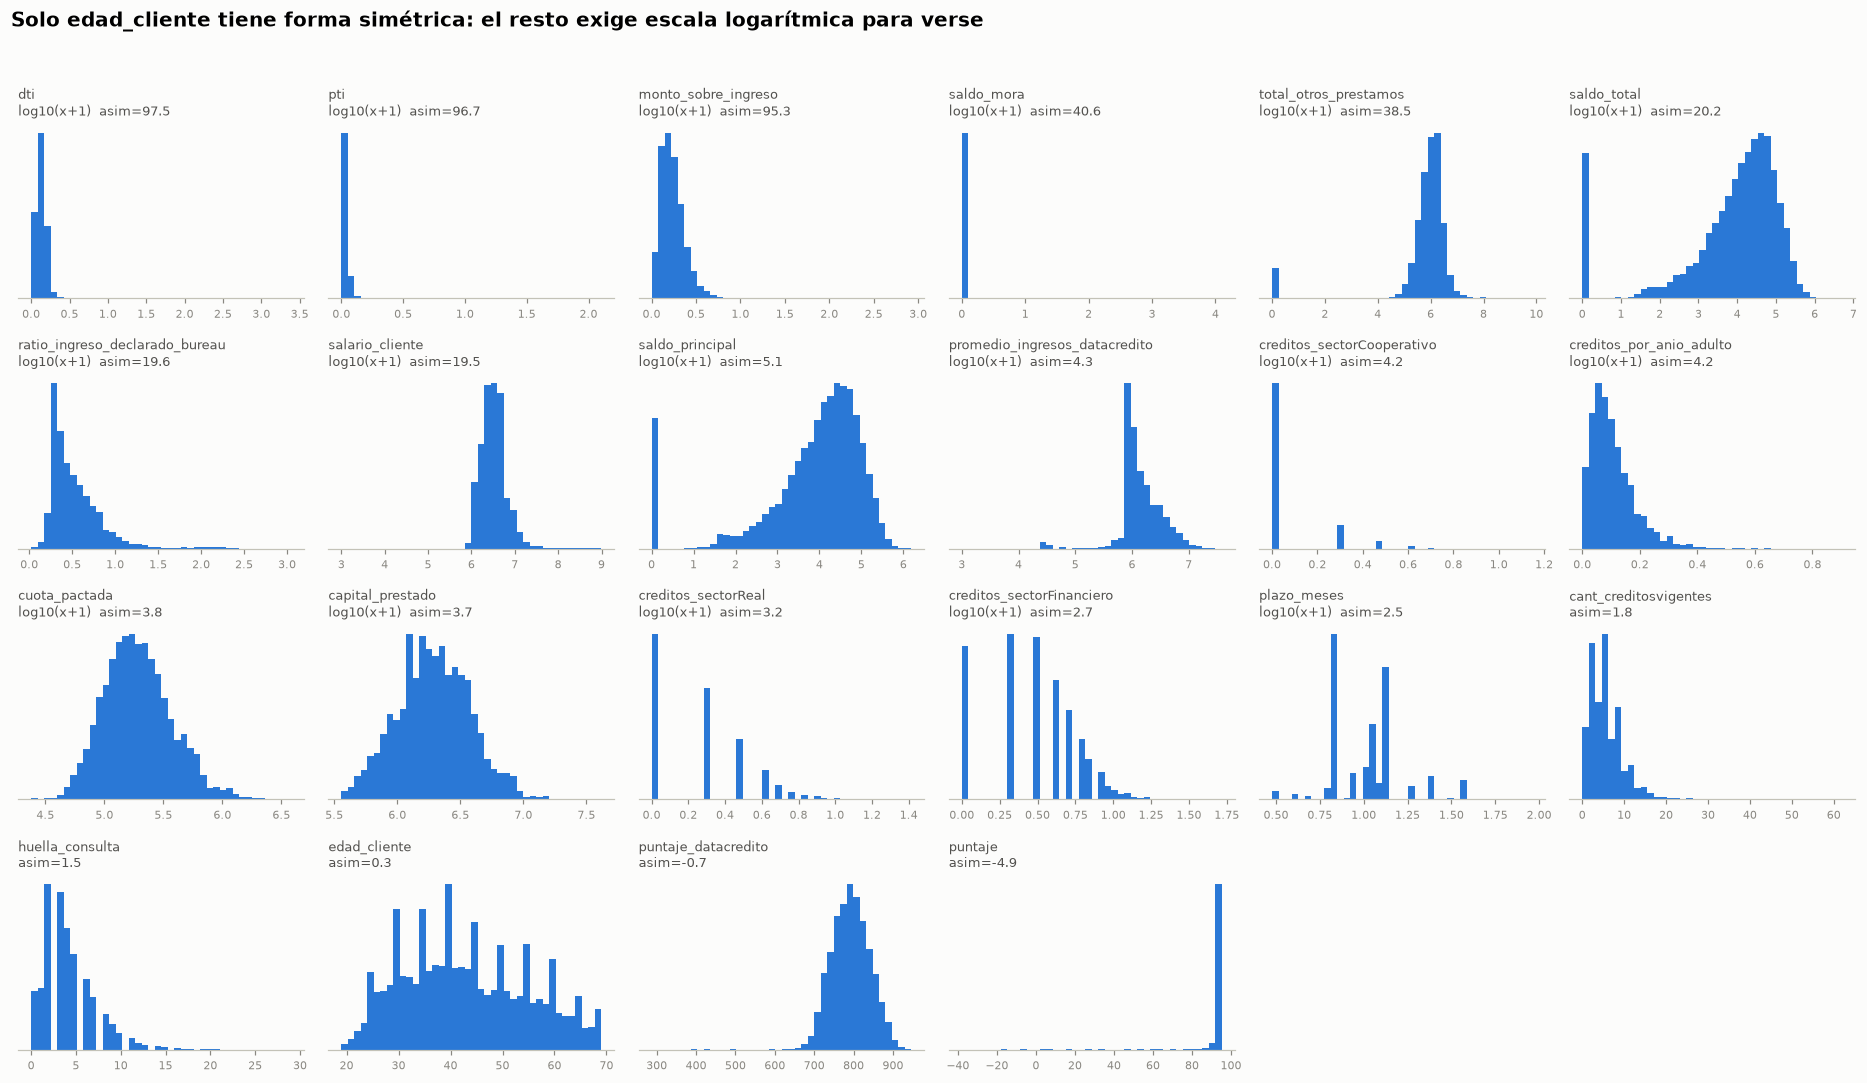

In [20]:
orden = X.skew().sort_values(ascending=False).index
fig, axes = plt.subplots(4, 6, figsize=(17, 10))

for ax, col in zip(axes.flat, orden):
    s = X[col].dropna()
    log = s.skew() > 2 and s.min() >= 0
    ax.hist(np.log10(s + 1) if log else s, bins=40, color=AZUL, edgecolor='none')
    ax.set_title(f'{col}\n{"log10(x+1)  " if log else ""}asim={s.skew():.1f}',
                 fontsize=8.5, color=TINTA2, fontweight='normal', pad=6)
    ax.set_yticks([])
    ax.tick_params(labelsize=7.5)
    ax.spines['left'].set_visible(False)

for ax in axes.flat[len(orden):]:
    ax.set_visible(False)

fig.suptitle('Solo edad_cliente tiene forma simétrica: el resto exige escala logarítmica para verse',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Lectura:** el panel confirma tres cosas. Primera, `capital_prestado` y `cuota_pactada` son
casi normales una vez en logaritmo, que es la firma de una variable log-normal. Segunda, varias
variables de conteo tienen una masa grande en cero (`saldo_mora`, `creditos_sectorCooperativo`,
`saldo_total`) que ninguna transformación continua va a arreglar. Tercera, `edad_cliente` muestra
picos regulares en múltiplos de 5: las edades vienen redondeadas en la captura, un detalle que
conviene conocer antes de construir bandas estrechas.

### 3.1.5 La variable objetivo

**Pregunta:** ¿Qué tan desbalanceada está la mora?

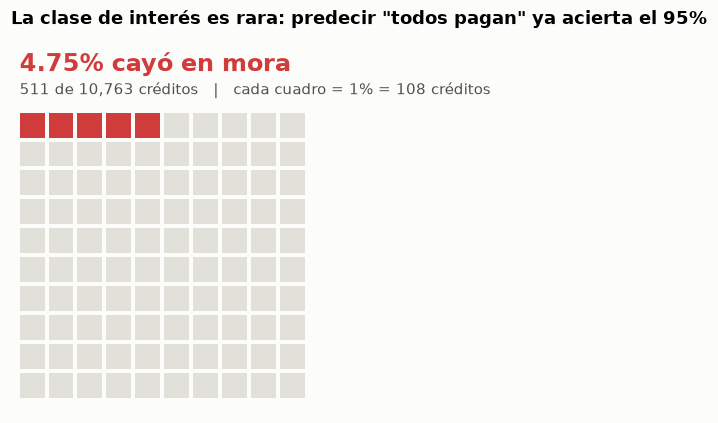

In [21]:
casos = int(mora.sum())
fig, ax = plt.subplots(figsize=(7.2, 4.4))

for i in range(100):
    fila, col = divmod(i, 10)
    ax.add_patch(plt.Rectangle((col, -fila), 0.86, 0.86,
                               facecolor=CRITICO if i < round(BASE) else '#e1e0d9', edgecolor='none'))

ax.set_xlim(-0.3, 10.3); ax.set_ylim(-9.5, 3.4); ax.set_aspect('equal'); ax.axis('off')
ax.annotate(f'{BASE:.2f}% cayó en mora', (0, 2.3), fontsize=16, fontweight='bold', color=CRITICO)
ax.annotate(f'{casos:,} de {len(df):,} créditos   |   cada cuadro = 1% = {len(df)/100:,.0f} créditos',
            (0, 1.5), fontsize=9.5, color=TINTA2)
ax.set_title('La clase de interés es rara: predecir "todos pagan" ya acierta el 95%', fontsize=12, pad=10)
plt.show()

**Lectura:** 511 créditos en mora sobre 10 763. Un clasificador que dijera "todos pagan" acertaría el
95.25% de las veces sin aprender nada, así que la exactitud queda descartada como métrica y el
modelado posterior tendrá que usar ponderación de clases o remuestreo. También implica que cualquier
subgrupo con menos de ~100 créditos tendrá un intervalo de confianza demasiado ancho para concluir.

### 3.1.6 Edad, la única variable simétrica

**Pregunta:** ¿Cómo se distribuye la edad de los clientes?

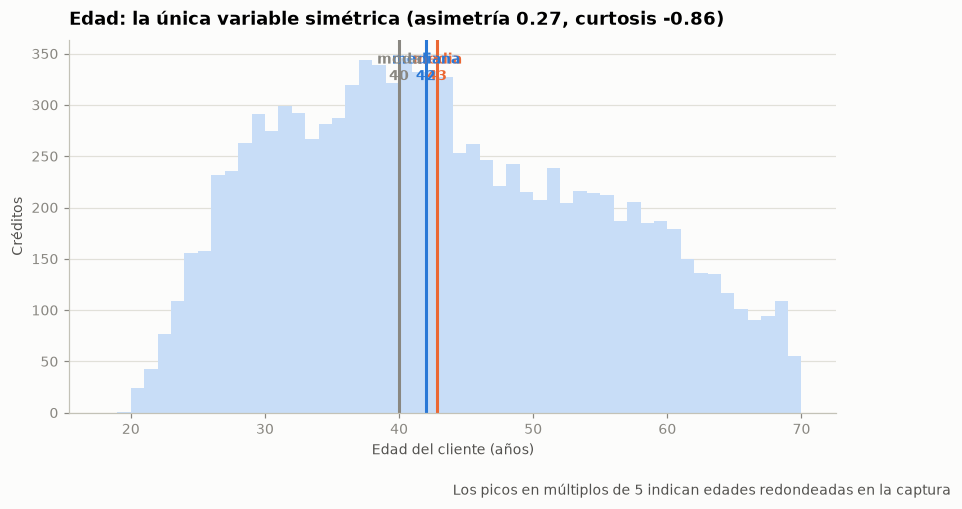

In [22]:
edad = X['edad_cliente'].dropna()
fig, ax = plt.subplots(figsize=(9, 4.4))

ax.hist(edad, bins=range(18, 71), color='#c8ddf7', edgecolor='none')
for etiqueta, valor, color in [('media', edad.mean(), NARANJA),
                               ('mediana', edad.median(), AZUL),
                               ('moda', edad.mode().iloc[0], GRIS)]:
    ax.axvline(valor, color=color, lw=2)
    ax.annotate(f'{etiqueta}\n{valor:.0f}', (valor, ax.get_ylim()[1] * 0.97),
                ha='center', va='top', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Edad del cliente (años)'); ax.set_ylabel('Créditos')
ax.grid(axis='y'); ax.set_axisbelow(True)
ax.set_title(f'Edad: la única variable simétrica (asimetría {edad.skew():.2f}, curtosis {edad.kurt():.2f})',
             pad=10)
ax.annotate('Los picos en múltiplos de 5 indican edades redondeadas en la captura',
            (0.5, -0.22), xycoords='axes fraction', fontsize=9, color=TINTA2)
plt.show()

### 3.1.7 Los montos en pesos

**Pregunta:** ¿Qué tan larga es la cola de los montos y dónde está el grueso de la cartera?

Se usa la función de distribución acumulada empírica en vez de un histograma porque permite leer
percentiles directamente y comparar tres variables de escalas distintas en un mismo eje.

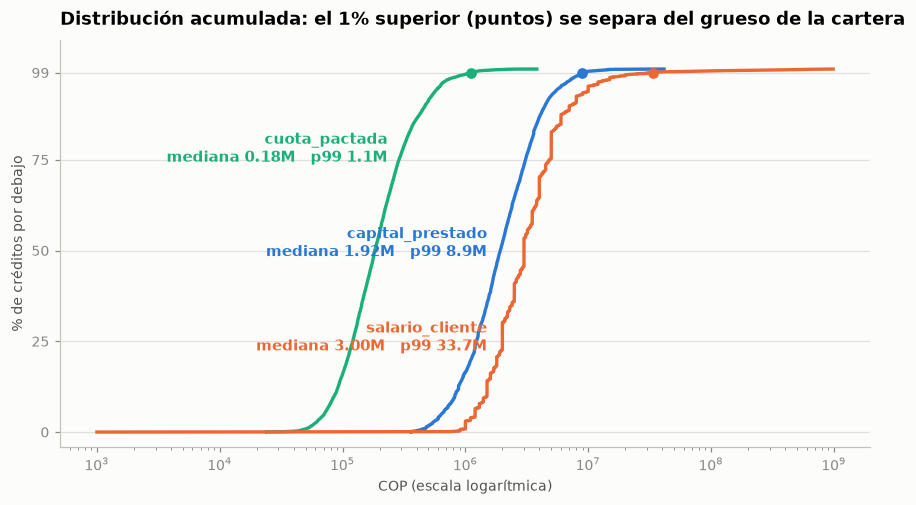

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
series = [('cuota_pactada', '#1baf7a', 78), ('capital_prestado', AZUL, 52), ('salario_cliente', NARANJA, 26)]

for col, color, ancla in series:
    s = X[col].dropna().sort_values()
    ax.plot(s, np.arange(1, len(s) + 1) / len(s) * 100, color=color, lw=2.2)
    p50, p99 = s.median(), s.quantile(.99)
    ax.annotate(f'{col}\nmediana {p50/1e6:.2f}M   p99 {p99/1e6:.1f}M',
                (s.quantile(ancla / 100), ancla), xytext=(-10, 0), textcoords='offset points',
                ha='right', va='center', fontsize=9.5, color=color, fontweight='bold')
    ax.plot([p99], [99], 'o', color=color, ms=6)

ax.set_xscale('log'); ax.set_xlabel('COP (escala logarítmica)'); ax.set_ylabel('% de créditos por debajo')
ax.set_yticks([0, 25, 50, 75, 99]); ax.set_ylim(-4, 108)
ax.grid(axis='y'); ax.set_axisbelow(True)
ax.set_title('Distribución acumulada: el 1% superior (puntos) se separa del grueso de la cartera', pad=10)
plt.show()

**Lectura:** la mediana de crédito es de 1.92 M COP con una cuota de 183 mil, sobre un ingreso
declarado mediano de 3 M. El percentil 99 se dispara a 8.9 M de crédito y 33.7 M de ingreso: entre la
mediana y el p99 hay casi un orden de magnitud. Cualquier modelo lineal sobre estos valores en bruto
quedaría dominado por el 1% superior.

### 3.1.8 Los dos scores

**Pregunta:** ¿Cómo se ve un score legítimo comparado con la variable que en 2.3 quedó marcada como fuga?

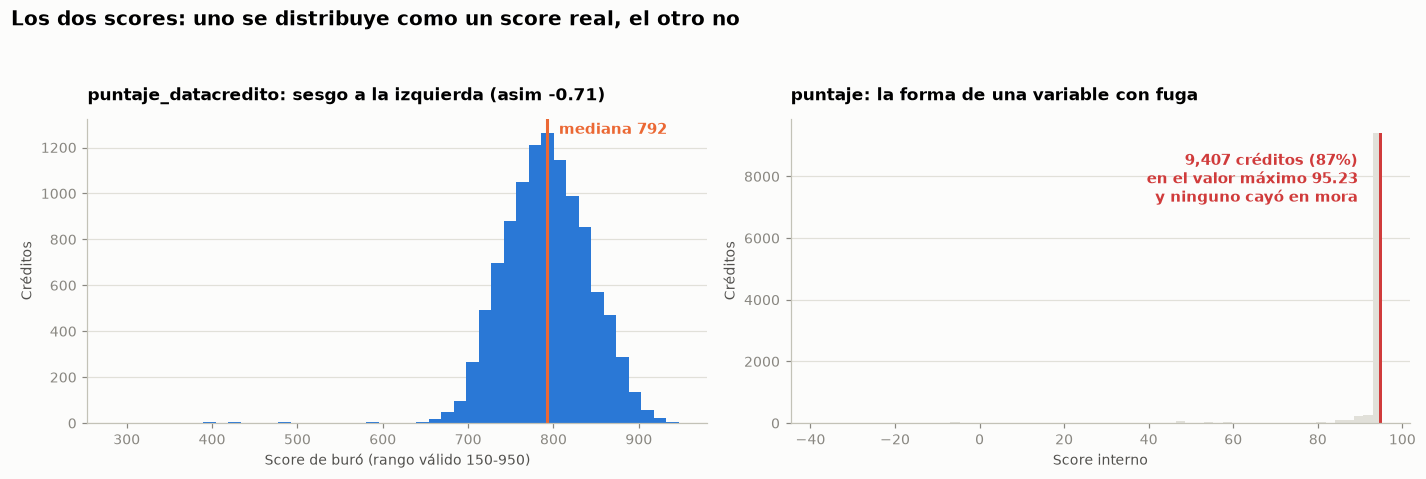

In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))

s = X['puntaje_datacredito'].dropna()
a1.hist(s, bins=45, color=AZUL, edgecolor='none')
a1.axvline(s.median(), color=NARANJA, lw=2)
a1.annotate(f'mediana {s.median():.0f}', (s.median(), a1.get_ylim()[1] * 0.95),
            xytext=(8, 0), textcoords='offset points', color=NARANJA, fontweight='bold', fontsize=9.5)
a1.set_title(f'puntaje_datacredito: sesgo a la izquierda (asim {s.skew():.2f})', fontsize=11)
a1.set_xlabel('Score de buró (rango válido 150-950)'); a1.set_ylabel('Créditos')
a1.grid(axis='y'); a1.set_axisbelow(True)

p = df['puntaje'].astype('float64')
pico = int((p == p.max()).sum())
a2.hist(p, bins=60, color='#e1e0d9', edgecolor='none')
a2.hist(p[p == p.max()], bins=[p.max() - 0.8, p.max()], color=CRITICO, edgecolor='none')
a2.annotate(f'{pico:,} créditos ({pico/len(df):.0%})\nen el valor máximo {p.max():.2f}\ny ninguno cayó en mora',
            (p.max(), pico), xytext=(-16, -12), textcoords='offset points', ha='right', va='top',
            fontsize=9.5, color=CRITICO, fontweight='bold')
a2.set_title('puntaje: la forma de una variable con fuga', fontsize=11)
a2.set_xlabel('Score interno'); a2.set_ylabel('Créditos')
a2.grid(axis='y'); a2.set_axisbelow(True)

fig.suptitle('Los dos scores: uno se distribuye como un score real, el otro no',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Lectura:** `puntaje_datacredito` tiene la forma esperada de un score de buró: unimodal, centrado en
792, con sesgo a la izquierda porque la cartera aprobada ya filtró a los peores perfiles.
`puntaje` no se parece en nada: el 87% de los créditos comparte exactamente el mismo valor máximo y
ninguno de ellos cayó en mora. Esa acumulación en un único punto es la firma de una variable
calculada después de conocer el resultado. Queda descartada como predictora.

### 3.1.9 Composición de la cartera

**Pregunta:** ¿Qué productos, perfiles laborales y rangos de edad componen la cartera?

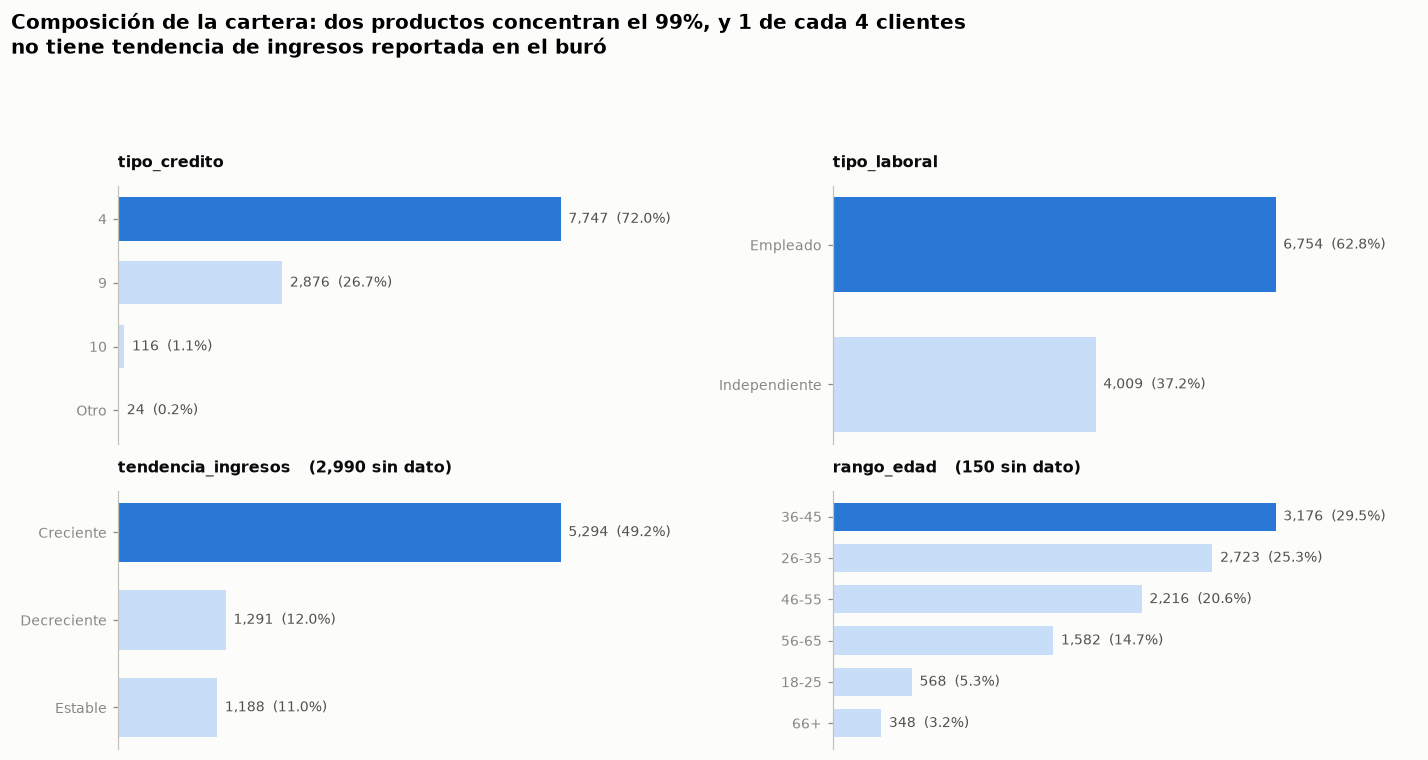

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, col in zip(axes.flat, ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'rango_edad']):
    vc = df[col].value_counts().sort_values()
    destacada = vc.idxmax()
    colores = [AZUL if i == destacada else '#c8ddf7' for i in vc.index]
    ax.barh([str(i) for i in vc.index], vc.values, color=colores, height=.68)
    for y, v in enumerate(vc.values):
        ax.annotate(f'{v:,}  ({v/len(df):.1%})', (v, y), xytext=(5, 0), textcoords='offset points',
                    va='center', fontsize=9, color=TINTA2)
    ax.set_xlim(0, vc.max() * 1.32)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False)
    faltantes = df[col].isna().sum()
    ax.set_title(f'{col}' + (f'   ({faltantes:,} sin dato)' if faltantes else ''),
                 fontsize=10.5, color=TINTA)

fig.suptitle('Composición de la cartera: dos productos concentran el 99%, y 1 de cada 4 clientes\n'
             'no tiene tendencia de ingresos reportada en el buró',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

**Lectura:** la cartera es más homogénea de lo que sugieren los 23 campos. Dos productos concentran
el 98.7% de los créditos, casi dos tercios de los clientes son empleados, y la edad se concentra
entre los 26 y los 55 años. El dato relevante para el análisis posterior es que **1 de cada 4
clientes no tiene tendencia de ingresos reportada en el buró**: ese bloque ausente se examina en 3.2.8.

### 3.1.10 Análisis de valores atípicos

**Pregunta:** cuantos valores extremos quedan después de la limpieza de la sección 2, y son errores
o cola legítima?

En 2.2 ya se anularon los centinelas (edades imposibles, scores fuera de rango, ingresos en cero o
absurdamente altos). Lo que queda aquí es cola real de la distribución, y la pregunta es si estorba.

In [26]:
def resumen_atipicos(s):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    valla = q3 + 1.5 * (q3 - q1)
    return pd.Series({'n': len(s), 'valla_sup_IQR': round(valla, 2),
                      'atipicos_IQR': int((s > valla).sum()),
                      'pct_IQR': round((s > valla).mean() * 100, 2),
                      'p99': round(s.quantile(.99), 2), 'max': round(s.max(), 2),
                      'max_sobre_p99': round(s.max() / s.quantile(.99), 1) if s.quantile(.99) > 0 else np.nan})

atipicos = X.apply(resumen_atipicos).T.sort_values('pct_IQR', ascending=False)
print(atipicos.to_string())

                                      n  valla_sup_IQR  atipicos_IQR  pct_IQR          p99           max  max_sobre_p99
creditos_sectorCooperativo      10763.0           0.00        1895.0    17.61         3.00  1.300000e+01            4.3
promedio_ingresos_datacredito    7826.0     4194305.62         783.0    10.01  10805379.25  3.810658e+07            3.5
saldo_principal                 10358.0      115045.62         951.0     9.18    325711.87  1.562285e+06            4.8
ratio_ingreso_declarado_bureau   7807.0           7.36         715.0     9.16        99.06  1.110970e+03           11.2
saldo_total                     10607.0      128108.00         970.0     9.14    367295.26  5.116066e+06           13.9
plazo_meses                     10763.0          21.00         869.0     8.07        36.00  9.000000e+01            2.5
cuota_pactada                   10763.0      538021.50         765.0     7.11   1114004.42  3.816752e+06            3.4
salario_cliente                 10717.0 

/tmp/ipykernel_33188/3417697895.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(datos, vert=False, tick_labels=dinero, widths=.6, patch_artist=True,


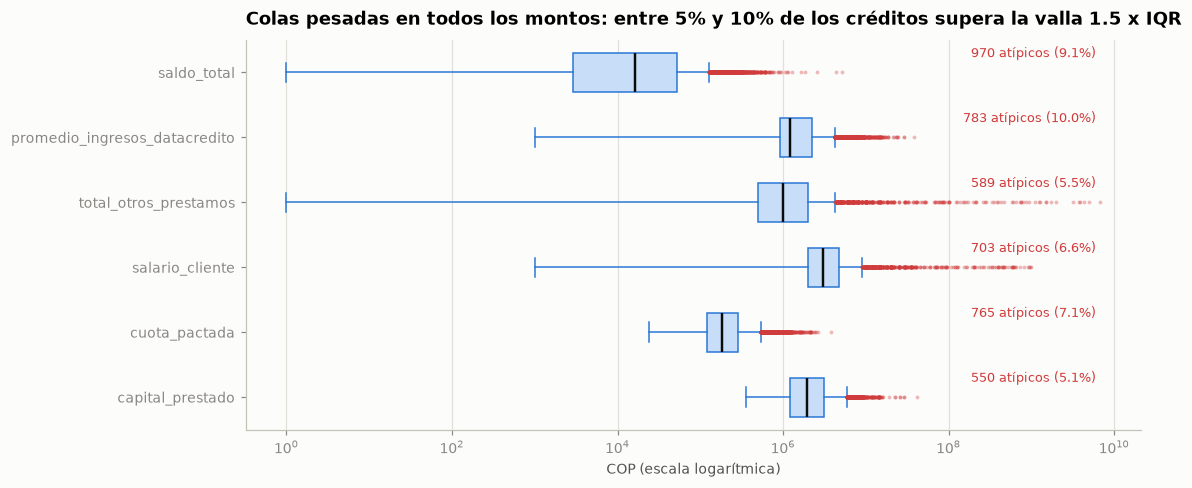

In [27]:
dinero = ['capital_prestado', 'cuota_pactada', 'salario_cliente', 'total_otros_prestamos',
          'promedio_ingresos_datacredito', 'saldo_total']
fig, ax = plt.subplots(figsize=(10.5, 4.6))

datos = [X[c].dropna().clip(lower=1) for c in dinero]
bp = ax.boxplot(datos, vert=False, tick_labels=dinero, widths=.6, patch_artist=True,
                flierprops=dict(marker='o', ms=2.5, mfc=CRITICO, mec='none', alpha=.35),
                medianprops=dict(color=TINTA, lw=1.6),
                boxprops=dict(facecolor='#c8ddf7', edgecolor=AZUL),
                whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL))

for y, c in enumerate(dinero, start=1):
    s = X[c].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    n = int((s > q3 + 1.5 * (q3 - q1)).sum())
    ax.annotate(f'{n:,} atípicos ({n/len(s):.1%})', (ax.get_xlim()[1], y), xytext=(-4, 10),
                textcoords='offset points', ha='right', fontsize=8.5, color=CRITICO)

ax.set_xscale('log'); ax.set_xlabel('COP (escala logarítmica)')
ax.grid(axis='x'); ax.set_axisbelow(True)
ax.set_title('Colas pesadas en todos los montos: entre 5% y 10% de los créditos supera la valla 1.5 x IQR', pad=10)
plt.show()

**Lectura:** entre el 5% y el 10% de los créditos supera la valla de 1.5 x IQR en cada variable de
dinero, lo cual es normal en distribuciones log-normales y no indica error. Lo que si merece atención
es la **relación entre el máximo y el percentil 99**: en `dti` el máximo es 1 739 veces el p99, en
`total_otros_prestamos` 378 veces y en `pti` 363 veces. Son pocos registros, pero bastan para
desestabilizar cualquier promedio o modelo lineal. No se eliminan (perderiamos casos de mora reales);
se recorta en el p99 al modelar, como se propone en 3.4.

### 3.1.11 Ventana temporal

**Pregunta:** ¿En qué periodo se desembolsaron estos créditos y cómo se reparte el volumen?

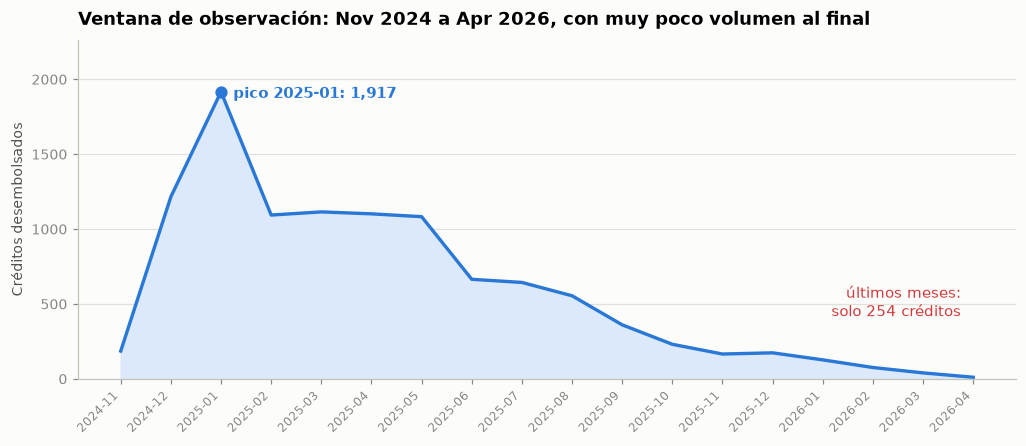

In [28]:
vol = df.groupby('mes_prestamo').size()
fig, ax = plt.subplots(figsize=(11, 4))

ax.fill_between(range(len(vol)), vol.values, color='#dbe9fb')
ax.plot(range(len(vol)), vol.values, color=AZUL, lw=2.2)
pico = vol.idxmax()
i = list(vol.index).index(pico)
ax.plot([i], [vol.max()], 'o', color=AZUL, ms=7)
ax.annotate(f'pico {pico}: {vol.max():,}', (i, vol.max()), xytext=(8, -4),
            textcoords='offset points', fontsize=9.5, color=AZUL, fontweight='bold')
ax.annotate(f'últimos meses:\nsolo {vol.iloc[-4:].sum():,} créditos', (len(vol) - 1, vol.iloc[-1]),
            xytext=(-8, 40), textcoords='offset points', ha='right', fontsize=9.5, color=CRITICO)

ax.set_xticks(range(len(vol))); ax.set_xticklabels(vol.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Créditos desembolsados'); ax.grid(axis='y'); ax.set_axisbelow(True)
ax.set_ylim(0, vol.max() * 1.18)
ax.set_title(f'Ventana de observación: {df["fecha_prestamo"].min():%b %Y} a {df["fecha_prestamo"].max():%b %Y}, '
             'con muy poco volumen al final', pad=10)
plt.show()

**Lectura:** la ventana va de noviembre de 2024 a abril de 2026, con el grueso concentrado en el
primer semestre de 2025 y una caída sostenida después. Los últimos cuatro meses suman apenas 254
créditos. Esa asimetría temporal tiene una consecuencia directa sobre la interpretación de la mora
que se examina en 3.2.9.

## 3.2 Análisis bivariable 

### 3.2.1 Qué variables se asocian con la mora

**Pregunta:** ¿De las 27 variables disponibles, cuáles tienen relación real con el incumplimiento y
qué tan fuerte es?

Se aplica a cada variable la prueba que corresponde a su tipo:

- **Numéricas**: Mann-Whitney U, que no supone normalidad (ninguna variable la cumple, ver 3.1.2).
  El tamaño de efecto es el **AUC**, la probabilidad de que un crédito en mora tenga un valor más
  alto que uno al día. 0.5 significa ninguna asociación.
- **Categóricas**: Chi-cuadrado con **V de Cramér** como tamaño de efecto.

Para comparar ambos en una sola escala, el AUC se reexpresa como `|2 x (AUC - 0.5)|`, que también va
de 0 a 1. Con 27 pruebas simultáneas el riesgo de falsos positivos es alto, así que se aplica
corrección de Bonferroni y, sobre todo, **se ordena por tamaño de efecto y no por valor p**.

In [29]:
ORIGEN = {
    **{c: 'Finanzas declaradas' for c in ['salario_cliente', 'total_otros_prestamos', 'dti', 'pti',
                                          'monto_sobre_ingreso', 'cuota_supera_salario']},
    **{c: 'Perfil del solicitante' for c in ['edad_cliente', 'tipo_laboral', 'rango_edad']},
    **{c: 'Producto' for c in ['capital_prestado', 'plazo_meses', 'cuota_pactada', 'tipo_credito']},
}

def origen(c):
    return ORIGEN.get(c, 'Buró de crédito')

filas = []
for c in numericas:
    if c == 'puntaje':
        continue
    s = X[c]
    a, b = s[mora].dropna(), s[~mora].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    filas.append({'variable': c, 'tipo': 'numérica', 'prueba': 'Mann-Whitney U',
                  'estadístico': u, 'p_valor': p, 'efecto': u / (len(a) * len(b)),
                  'nombre_efecto': 'AUC', 'n_mora': len(a), 'n_aldia': len(b)})

for c in categoricas:
    tabla = pd.crosstab(df[c], mora)
    chi2, p, _, _ = stats.chi2_contingency(tabla)
    n = tabla.values.sum()
    filas.append({'variable': c, 'tipo': 'categórica', 'prueba': 'Chi-cuadrado',
                  'estadístico': chi2, 'p_valor': p,
                  'efecto': np.sqrt(chi2 / (n * (min(tabla.shape) - 1))),
                  'nombre_efecto': "Cramér V", 'n_mora': int(tabla[True].sum()),
                  'n_aldia': int(tabla[False].sum())})

bivariado = pd.DataFrame(filas)
bivariado['fuerza'] = np.where(bivariado['tipo'] == 'numérica',
                               (bivariado['efecto'] - 0.5).abs() * 2, bivariado['efecto'])
bivariado['origen'] = bivariado['variable'].map(origen)
bivariado['significativa'] = bivariado['p_valor'] < 0.05 / len(bivariado)
bivariado = bivariado.sort_values('fuerza', ascending=False).reset_index(drop=True)

print(bivariado[['variable', 'origen', 'prueba', 'p_valor', 'nombre_efecto', 'efecto',
                 'fuerza', 'significativa', 'n_mora']]
      .assign(p_valor=lambda d: d['p_valor'].apply(lambda v: f'{v:.2e}'),
              efecto=lambda d: d['efecto'].round(3), fuerza=lambda d: d['fuerza'].round(3))
      .to_string(index=False))
print(f'\nUmbral de significancia con corrección de Bonferroni para {len(bivariado)} pruebas: '
      f'p < {0.05/len(bivariado):.2e}')

                      variable                 origen         prueba  p_valor nombre_efecto  efecto  fuerza  significativa  n_mora
           puntaje_datacredito        Buró de crédito Mann-Whitney U 7.91e-21           AUC   0.376   0.248           True     500
               huella_consulta        Buró de crédito Mann-Whitney U 3.91e-14           AUC   0.598   0.196           True     511
                  edad_cliente Perfil del solicitante Mann-Whitney U 1.00e-08           AUC   0.424   0.152           True     500
ratio_ingreso_declarado_bureau        Buró de crédito Mann-Whitney U 3.32e-06           AUC   0.574   0.148           True     342
 promedio_ingresos_datacredito        Buró de crédito Mann-Whitney U 4.50e-06           AUC   0.427   0.146           True     343
              capital_prestado               Producto Mann-Whitney U 1.33e-05           AUC   0.557   0.114           True     511
             tiene_mora_bureau        Buró de crédito   Chi-cuadrado 6.89e-27      

**Lectura:** dos advertencias que la tabla deja claras.

`saldo_mora` tiene el segundo valor p más pequeño de toda la tabla (1e-28) y a la vez uno de los
tamaños de efecto más bajos (AUC 0.518). No es contradictorio: la variable es cero en el 99.5% de
las filas, y con ese volumen de empates el estadístico se vuelve enorme sin que la separación sea
útil. Es el ejemplo de por que aquí se ordena por efecto y no por significancia.

En sentido contrario, `dti` es significativa pero **con el signo invertido** (AUC 0.452): los
clientes que caen en mora tienen un endeudamiento declarado algo **menor**. Con `salario_cliente` sin
ninguna asociación (AUC 0.505), la explicación más probable es que el ingreso declarado no es
confiable, y por tanto los ratios construidos sobre el tampoco.

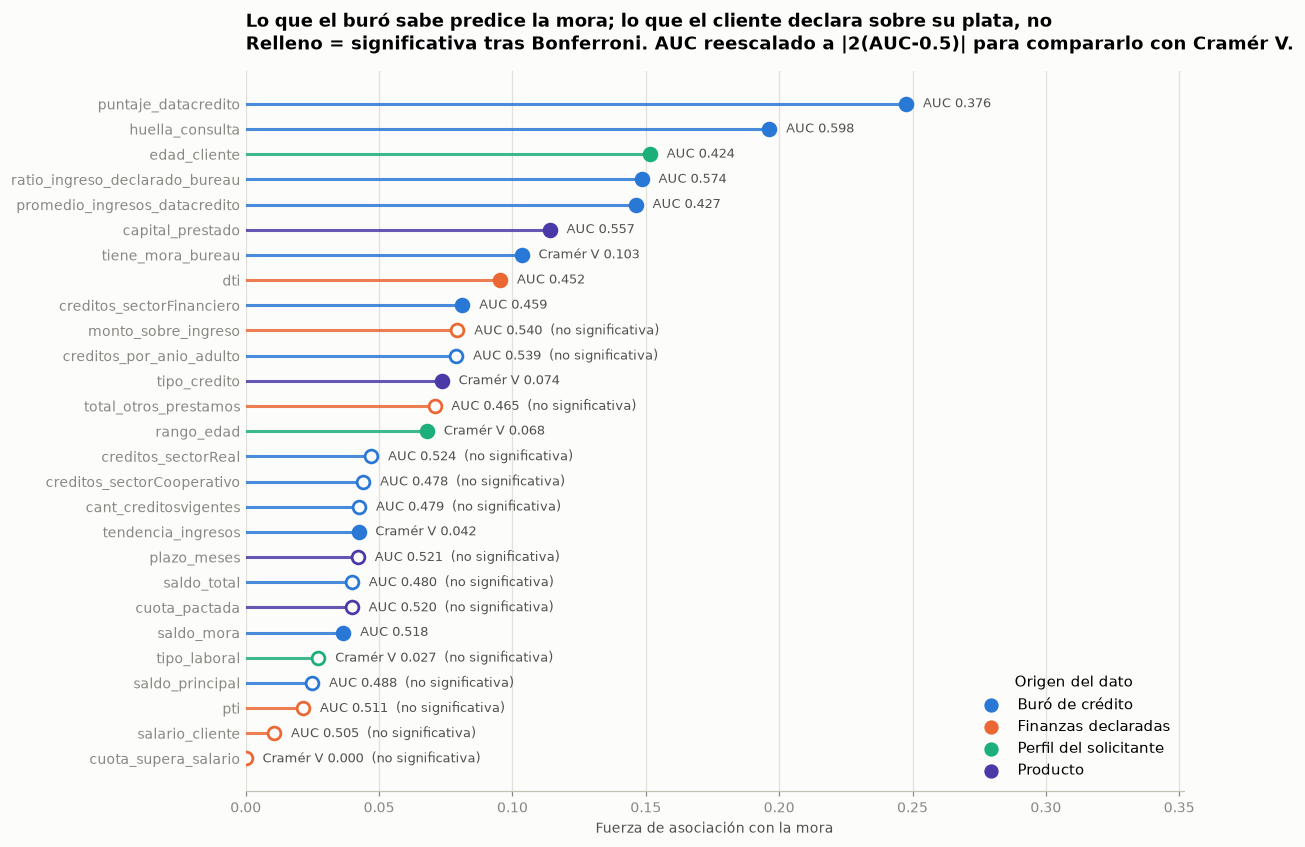

In [30]:
COLOR_ORIGEN = {'Buró de crédito': AZUL, 'Finanzas declaradas': NARANJA,
                'Perfil del solicitante': '#1baf7a', 'Producto': '#4a3aa7'}

d = bivariado.sort_values('fuerza')
fig, ax = plt.subplots(figsize=(11, 8.5))

for y, (_, r) in enumerate(d.iterrows()):
    color = COLOR_ORIGEN[r['origen']]
    ax.plot([0, r['fuerza']], [y, y], color=color, lw=2, alpha=.85, zorder=1)
    ax.scatter(r['fuerza'], y, s=70, zorder=2, color=color if r['significativa'] else '#fcfcfb',
               edgecolor=color, linewidth=1.8)
    nota = f"{r['nombre_efecto']} {r['efecto']:.3f}" + ('' if r['significativa'] else '  (no significativa)')
    ax.annotate(nota, (r['fuerza'], y), xytext=(11, 0), textcoords='offset points',
                va='center', fontsize=8.5, color=TINTA2)

ax.set_yticks(range(len(d))); ax.set_yticklabels(d['variable'], fontsize=9)
ax.set_xlim(0, d['fuerza'].max() * 1.42); ax.set_xlabel('Fuerza de asociación con la mora')
ax.grid(axis='x'); ax.set_axisbelow(True); ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

for origen_nombre, color in COLOR_ORIGEN.items():
    ax.scatter([], [], s=70, color=color, label=origen_nombre)
ax.legend(loc='lower right', fontsize=9.5, title='Origen del dato', title_fontsize=9.5)

ax.set_title('Lo que el buró sabe predice la mora; lo que el cliente declara sobre su plata, no\n'
             + r'$\bf{Relleno}$ = significativa tras Bonferroni. AUC reescalado a |2(AUC-0.5)| '
               'para compararlo con Cramér V.', pad=14)
plt.show()

**Lectura, y es el hallazgo principal del análisis:** las cuatro variables más asociadas a la mora
vienen del buró o del contraste con el buró. Las finanzas que declara el cliente ocupan el fondo de
la tabla: `salario_cliente` (AUC 0.505), `pti` (0.511) y `cuota_supera_salario` (V de Cramér 0.000)
no distinguen nada.

La consecuencia para el negocio es concreta: la capacidad de pago declarada, que es lo que
tradicionalmente sostiene la decisión de crédito, **no esta prediciendo el incumplimiento en esta
cartera**. Lo que si predice es el historial que reporta el buró y, muy en particular, la
discrepancia entre lo que el cliente dice ganar y lo que el buró estima que gana.

### 3.2.2 El score de buró contra la mora

**Pregunta:** ¿Funciona el score de DataCrédito como ordenador de riesgo en esta cartera?

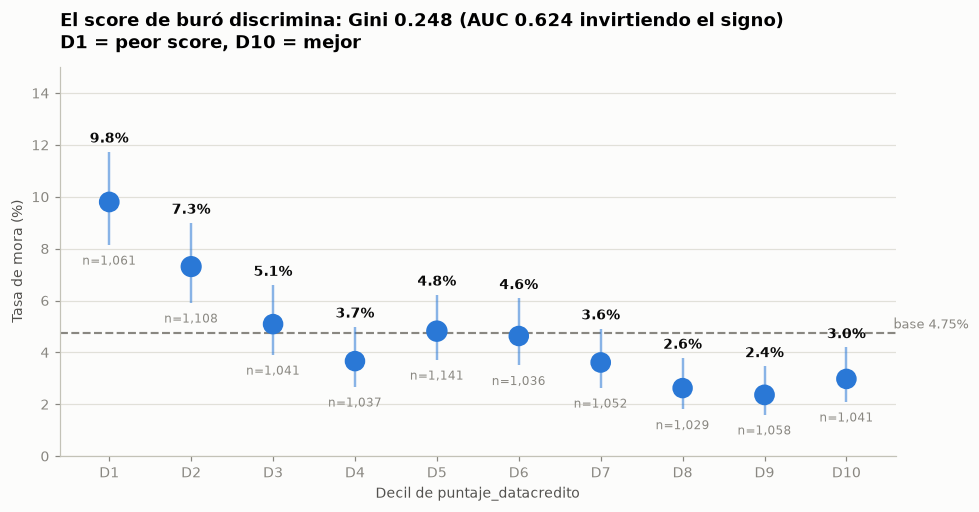

In [31]:
decil = pd.qcut(X['puntaje_datacredito'], 10, labels=[f'D{i}' for i in range(1, 11)])
a, b = X['puntaje_datacredito'][mora].dropna(), X['puntaje_datacredito'][~mora].dropna()
auc = stats.mannwhitneyu(a, b, alternative='two-sided').statistic / (len(a) * len(b))

grafico_gradiente(decil, f'El score de buró discrimina: Gini {abs(2*auc-1):.3f} (AUC {1-auc:.3f} invirtiendo el signo)\n'
                         'D1 = peor score, D10 = mejor',
                  'Decil de puntaje_datacredito')
plt.show()

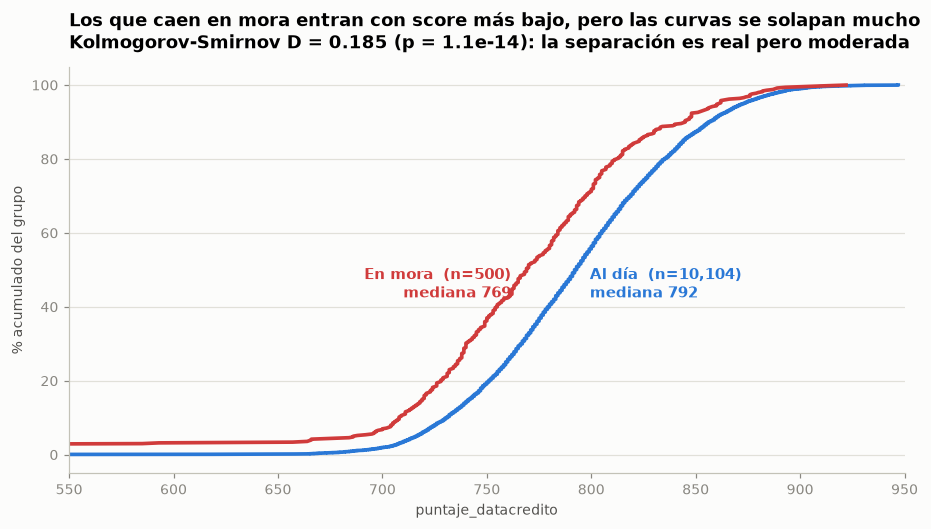

In [32]:
fig, ax = plt.subplots(figsize=(9.8, 4.8))

for etiqueta, mascara, color in [('Al día', ~mora, AZUL), ('En mora', mora, CRITICO)]:
    s = X['puntaje_datacredito'][mascara].dropna().sort_values()
    ax.plot(s, np.arange(1, len(s) + 1) / len(s) * 100, color=color, lw=2.4)
    ax.annotate(f'{etiqueta}  (n={len(s):,})\nmediana {s.median():.0f}',
                (s.median(), 50), xytext=(10 if etiqueta == 'Al día' else -10, -18),
                textcoords='offset points', ha='left' if etiqueta == 'Al día' else 'right',
                fontsize=10, fontweight='bold', color=color)

ks = stats.ks_2samp(X['puntaje_datacredito'][mora].dropna(), X['puntaje_datacredito'][~mora].dropna())
ax.set_xlabel('puntaje_datacredito'); ax.set_ylabel('% acumulado del grupo')
ax.set_xlim(550, 950); ax.grid(axis='y'); ax.set_axisbelow(True)
ax.set_title('Los que caen en mora entran con score más bajo, pero las curvas se solapan mucho\n'
             f'Kolmogorov-Smirnov D = {ks.statistic:.3f} (p = {ks.pvalue:.1e}): la separación es real pero moderada',
             pad=12)
plt.show()

**Lectura:** si funciona, y de forma casi monótona: del decil peor al mejor la mora cae de 9.8% a
3.0%, un factor de 3.3. El Gini de 0.248 es modesto para un score de buró pero perfectamente
utilizable, y coherente con que la cartera ya esta filtrada por políticas de originación. El único
tramo que rompe la monotonía es D10 (3.0% frente a 2.4% de D9), diferencia que cabe holgadamente
dentro de los intervalos de confianza.

La curva acumulada confirma la misma historia desde otro angulo: las distribuciones están corridas
pero se solapan mucho. El score ordena bien en promedio, no separa individuos.

### 3.2.3 Consultas recientes al buró

**Pregunta:** el número de consultas al buró anticipa el incumplimiento?

Es la huella que dejan otras entidades al evaluar al mismo cliente. En riesgo de crédito se
interpreta como intensidad de busqueda de financiación.

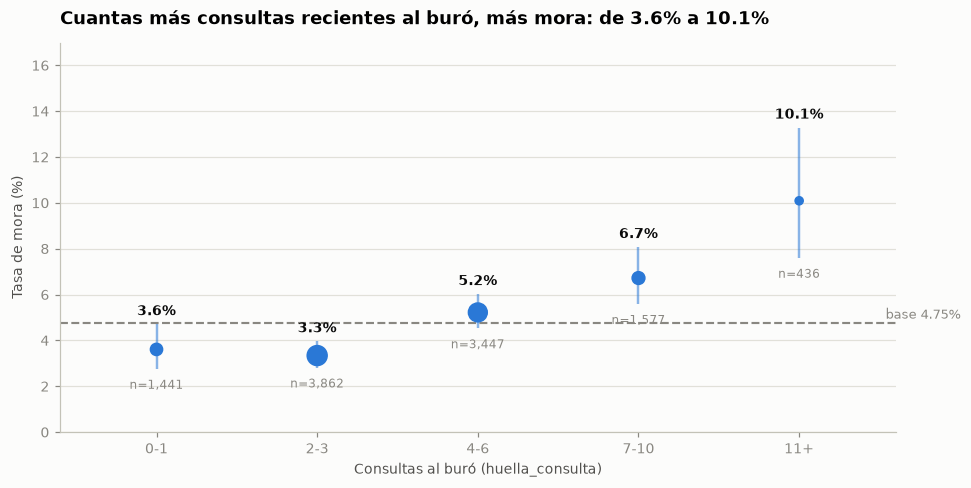

In [33]:
bandas = pd.cut(df['huella_consulta'], [-1, 1, 3, 6, 10, 30],
                labels=['0-1', '2-3', '4-6', '7-10', '11+'])
grafico_gradiente(bandas, 'Cuantas más consultas recientes al buró, más mora: de 3.6% a 10.1%',
                  'Consultas al buró (huella_consulta)')
plt.show()

**Lectura:** es el gradiente más limpio de todo el análisis y con tamaños de muestra amplios. De
0-1 consultas (3.6%) a 11 o más (10.1%) la mora casi se triplica, y los intervalos de los extremos no
se solapan. Un cliente que esta tocando muchas puertas a la vez es materialmente más riesgoso, y esta
sola variable ya permite una regla de negocio.

### 3.2.4 El plazo del crédito

**Pregunta:** ¿Los créditos a plazo largo caen más en mora?

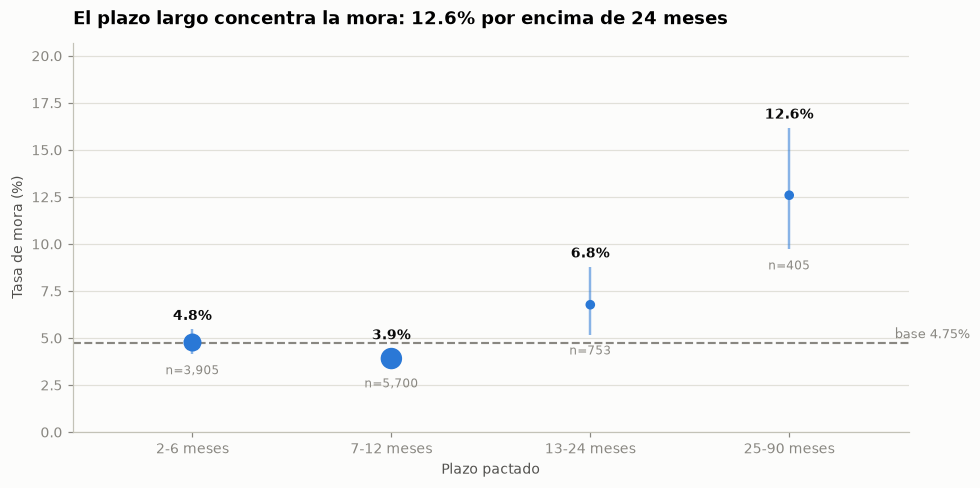

In [34]:
plazos = pd.cut(df['plazo_meses'], [0, 6, 12, 24, 90],
                labels=['2-6 meses', '7-12 meses', '13-24 meses', '25-90 meses'])
grafico_gradiente(plazos, 'El plazo largo concentra la mora: 12.6% por encima de 24 meses',
                  'Plazo pactado')
plt.show()

**Lectura:** por encima de 24 meses la mora llega a 12.6%, 2.6 veces la base. Pero esta lectura
requiere una advertencia importante: dentro de una ventana de observación fija, un crédito a 36 meses
ha tenido **más tiempo de exposición** para caer en mora que uno a 6 meses. Parte de este gradiente es
riesgo real y parte es un artefacto de la ventana. Separar ambos efectos exige saber la fecha de la
mora, que no esta en la base. Se reporta como hallazgo con esa reserva explicita.

Notese además que el tramo de 7-12 meses (3.9%) tiene **menos** mora que el de 2-6 meses (4.8%), así
que la relación no es simplemente creciente.

### 3.2.5 La edad del cliente

**Pregunta:** ¿¿La edad ordena el riesgo?

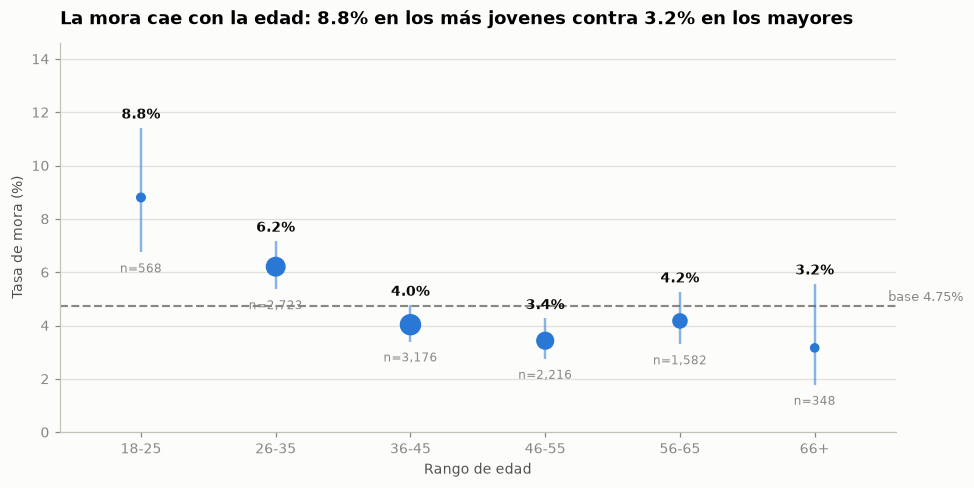

In [35]:
grafico_gradiente(df['rango_edad'], 'La mora cae con la edad: 8.8% en los más jovenes contra 3.2% en los mayores',
                  'Rango de edad')
plt.show()

**Lectura:** la mora cae de 8.8% en los clientes de 18 a 25 años a 3.4% entre los 46 y 55, y se
mantiene baja después. Es la variable de la solicitud con más señal (AUC 0.424) y la única que
compite con las del buró. El repunte de 56-65 (4.2%) esta dentro del intervalo del tramo anterior,
así que no se interpreta como cambio de tendencia.

### 3.2.6 El dato faltante como señal

**Pregunta:** ¿Los clientes sobre los que falta información son más riesgosos que aquellos con el
registro completo?

En 2.1 se documento que el bloque de ingresos del buró falta como unidad en el 27% de los casos. Si
la ausencia estuviera relacionada con el riesgo, imputar sin dejar rastro destruiría información.

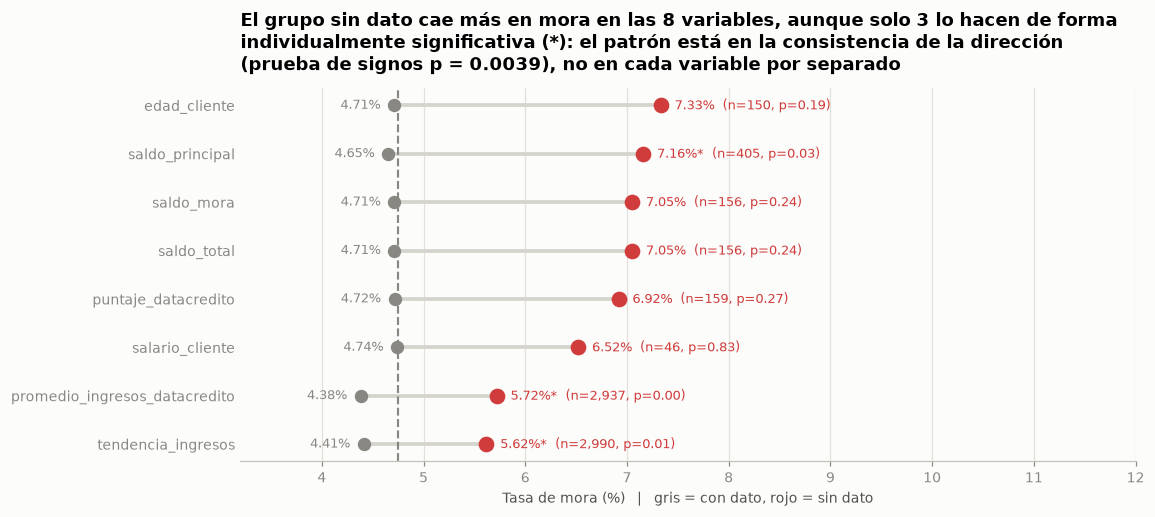

                     variable  n_ausente  mora_ausente  mora_presente    p
           tendencia_ingresos       2990          5.62           4.41 0.01
promedio_ingresos_datacredito       2937          5.72           4.38 0.00
              salario_cliente         46          6.52           4.74 0.83
          puntaje_datacredito        159          6.92           4.72 0.27
                  saldo_total        156          7.05           4.71 0.24
                   saldo_mora        156          7.05           4.71 0.24
              saldo_principal        405          7.16           4.65 0.03
                 edad_cliente        150          7.33           4.71 0.19

Dirección consistente en 8 de 8 variables. Prueba de signos: p = 0.0039.
Las tasas del grupo ausente descansan sobre muestras pequeñas (150-2 937), así que el chi-cuadrado
individual casi nunca alcanza significancia; lo informativo es que ninguna apunta en sentido contrario.
Advertencia: las 8 columnas no son independiente

In [36]:
originales = ['edad_cliente', 'salario_cliente', 'puntaje_datacredito', 'saldo_mora', 'saldo_total',
              'saldo_principal', 'promedio_ingresos_datacredito', 'tendencia_ingresos']
filas = []
for c in originales:
    falta = df[c].isna()
    t = tasa_mora(falta.map({True: 'ausente', False: 'presente'}))
    filas.append({'variable': c, 'n_ausente': int(t.loc['ausente', 'n']),
                  'mora_ausente': t.loc['ausente', 'tasa'], 'mora_presente': t.loc['presente', 'tasa'],
                  'p': stats.chi2_contingency(pd.crosstab(falta, mora))[1]})

nulos_senial = pd.DataFrame(filas).sort_values('mora_ausente')
signo = stats.binomtest((nulos_senial['mora_ausente'] > nulos_senial['mora_presente']).sum(),
                        len(nulos_senial), 0.5, alternative='greater')

fig, ax = plt.subplots(figsize=(10.5, 4.4))
y = np.arange(len(nulos_senial))
ax.axvline(BASE, color=GRIS, lw=1.4, ls='--')
ax.annotate(f'base {BASE:.2f}%', (BASE, len(y) - .35), xytext=(4, 0), textcoords='offset points',
            fontsize=8.5, color=GRIS)
ax.hlines(y, nulos_senial['mora_presente'], nulos_senial['mora_ausente'], color='#d5d4cd', lw=2.5, zorder=1)
ax.scatter(nulos_senial['mora_presente'], y, s=60, color=GRIS, zorder=2)
ax.scatter(nulos_senial['mora_ausente'], y, s=75, zorder=2, color=CRITICO,
           edgecolor=CRITICO, linewidth=1.6)

for yi, (_, r) in zip(y, nulos_senial.iterrows()):
    marca = '*' if r['p'] < 0.05 else ''
    ax.annotate(f"{r['mora_ausente']:.2f}%{marca}  (n={int(r['n_ausente']):,}, p={r['p']:.2f})",
                (r['mora_ausente'], yi), xytext=(9, 0), textcoords='offset points', va='center',
                fontsize=8.5, color=CRITICO)
    ax.annotate(f"{r['mora_presente']:.2f}%", (r['mora_presente'], yi), xytext=(-9, 0),
                textcoords='offset points', va='center', ha='right', fontsize=8.5, color=GRIS)

ax.set_yticks(y); ax.set_yticklabels(nulos_senial['variable'], fontsize=9)
ax.set_xlim(3.2, 12); ax.set_xlabel('Tasa de mora (%)   |   gris = con dato, rojo = sin dato')
ax.grid(axis='x'); ax.set_axisbelow(True); ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
n_sig = int((nulos_senial['p'] < 0.05).sum())
ax.set_title(f'El grupo sin dato cae más en mora en las {len(nulos_senial)} variables, aunque solo {n_sig} lo hacen de forma\n'
             f'individualmente significativa (*): el patrón está en la consistencia de la dirección\n'
             f'(prueba de signos p = {signo.pvalue:.4f}), no en cada variable por separado', pad=12)
plt.show()

print(nulos_senial.assign(p=lambda d: d['p'].round(4)).round(2).to_string(index=False))
print(f'\nDirección consistente en {(nulos_senial["mora_ausente"] > nulos_senial["mora_presente"]).sum()} '
      f'de {len(nulos_senial)} variables. Prueba de signos: p = {signo.pvalue:.4f}.')
print('Las tasas del grupo ausente descansan sobre muestras pequeñas (150-2 937), así que el chi-cuadrado')
print('individual casi nunca alcanza significancia; lo informativo es que ninguna apunta en sentido contrario.')
print('Advertencia: las 8 columnas no son independientes (saldo_mora y saldo_total comparten las mismas 156')
print('filas; tendencia_ingresos y promedio_ingresos_datacredito faltan casi siempre juntas), así que la')
print('prueba de signos sobreestima la evidencia. Se reporta como indicio, no como prueba concluyente.')

**Lectura:** la dirección es la misma en las ocho variables con nulos: el grupo sin dato siempre cae
más en mora. Ahora bien, **solo tres alcanzan significancia individual**, porque los grupos de
ausentes son pequeños (150 a 405 filas en cinco de los ocho casos). Lo que sostiene la conclusión no
es cada prueba por separado sino la consistencia de la dirección, y aun así con la reserva de que las
columnas no son independientes entre si.

Conclusión practica y suficientemente respaldada: al imputar hay que **conservar un indicador
booleano de ausencia** por variable, porque el hecho de faltar carga información.

### 3.2.7 Censura por cosecha

**Pregunta:** ¿Es comparable la tasa de mora entre créditos desembolsados en meses distintos?

Es la pregunta más importante de esta sección, porque si la respuesta es no, todas las comparaciones
anteriores están contaminadas en alguna medida.

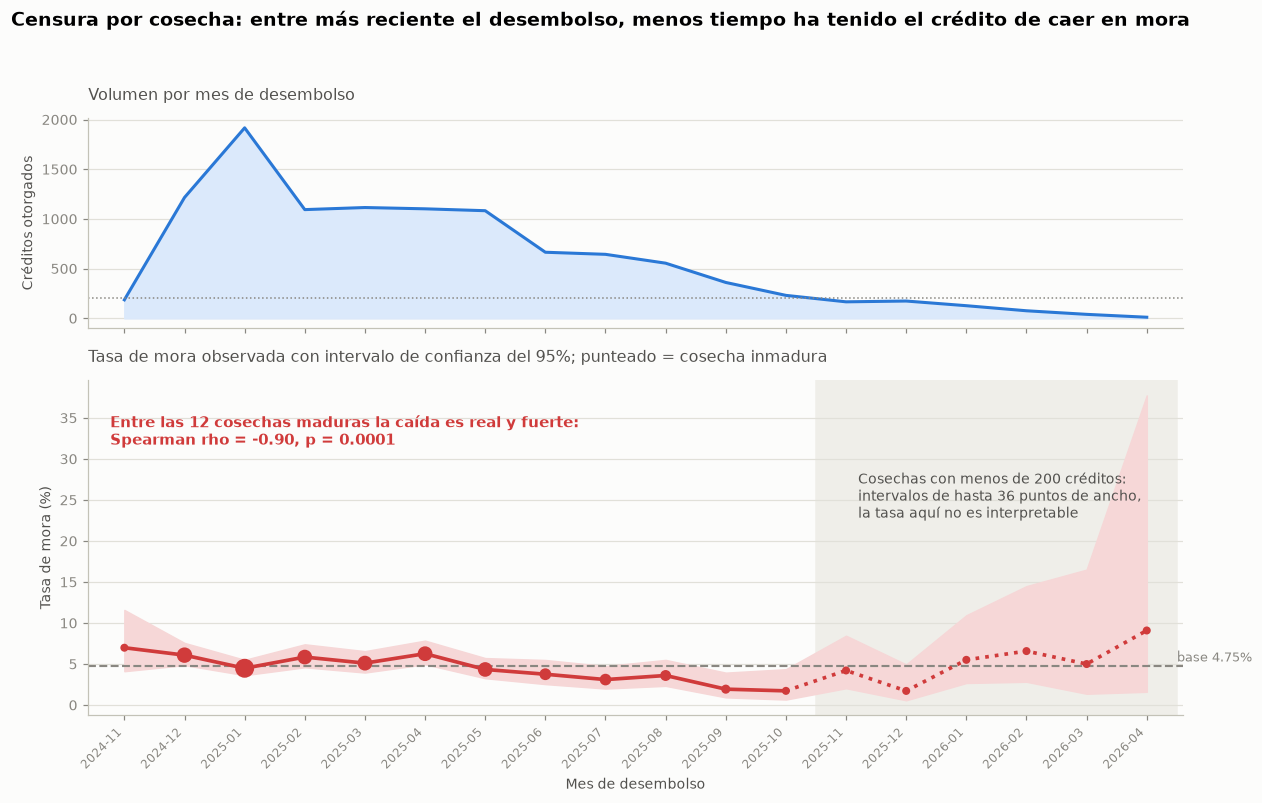

                 n  casos  tasa    lo     hi
mes_prestamo                                
2024-11        186     13  6.99  4.13  11.59
2024-12       1216     74  6.09  4.88   7.57
2025-01       1917     86  4.49  3.65   5.51
2025-02       1094     64  5.85  4.61   7.40
2025-03       1115     57  5.11  3.97   6.57
2025-04       1102     69  6.26  4.98   7.85
2025-05       1083     47  4.34  3.28   5.72
2025-06        665     25  3.76  2.56   5.49
2025-07        644     20  3.11  2.02   4.75
2025-08        555     20  3.60  2.34   5.50
2025-09        361      7  1.94  0.94   3.95
2025-10        231      4  1.73  0.68   4.37
2025-11        166      7  4.22  2.06   8.45
2025-12        174      3  1.72  0.59   4.95
2026-01        127      7  5.51  2.70  10.94
2026-02         76      5  6.58  2.84  14.49
2026-03         40      2  5.00  1.38  16.50
2026-04         11      1  9.09  1.62  37.74

Tendencia sobre las 18 cosechas:            Spearman rho = -0.152, p = 0.5479
Tendencia sobre las 1

In [37]:
cosecha = tasa_mora(df['mes_prestamo'])
x = np.arange(len(cosecha))
corte = int(np.where(cosecha['n'].values >= 200)[0].max()) + 1     # inicio del tramo con poco volumen
maduras = cosecha.iloc[:corte]

rho_t, p_t = stats.spearmanr(x, cosecha['tasa'])
rho_m, p_m = stats.spearmanr(np.arange(corte), maduras['tasa'])

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 7.4), sharex=True,
                             gridspec_kw={'height_ratios': [1, 1.6]})

a1.fill_between(x, cosecha['n'], color='#dbe9fb')
a1.plot(x, cosecha['n'], color=AZUL, lw=2)
a1.axhline(200, color=GRIS, lw=1, ls=':')
a1.set_ylabel('Créditos otorgados'); a1.grid(axis='y'); a1.set_axisbelow(True)
a1.set_title('Volumen por mes de desembolso', fontsize=10.5, color=TINTA2, fontweight='normal')

a2.axvspan(corte - .5, x[-1] + .5, color='#efeee9', zorder=0)
a2.axhline(BASE, color=GRIS, lw=1.4, ls='--')
a2.annotate(f'base {BASE:.2f}%', (x[-1] + .4, BASE), xytext=(4, 3), textcoords='offset points',
            fontsize=8.5, color=GRIS)
a2.fill_between(x, cosecha['lo'], cosecha['hi'], color='#f6d7d7')
a2.plot(x[:corte], cosecha['tasa'][:corte], color=CRITICO, lw=2.4)
a2.plot(x[corte - 1:], cosecha['tasa'][corte - 1:], color=CRITICO, lw=2.4, ls=':')
a2.scatter(x, cosecha['tasa'], s=np.clip(cosecha['n'] / cosecha['n'].max() * 130, 18, 130),
           color=CRITICO, zorder=3)
a2.annotate('Cosechas con menos de 200 créditos:\nintervalos de hasta 36 puntos de ancho,\nla tasa aquí no es interpretable',
            (corte + .2, a2.get_ylim()[1] * .72), fontsize=9, color=TINTA2, va='top')
a2.annotate(f'Entre las 12 cosechas maduras la caída es real y fuerte:\nSpearman rho = {rho_m:.2f}, p = {p_m:.4f}',
            (0.02, 0.9), xycoords='axes fraction', fontsize=9.5, color=CRITICO,
            fontweight='bold', va='top')

a2.set_ylabel('Tasa de mora (%)'); a2.grid(axis='y'); a2.set_axisbelow(True)
a2.set_xticks(x); a2.set_xticklabels(cosecha.index, rotation=45, ha='right', fontsize=8)
a2.set_xlabel('Mes de desembolso'); a2.set_xlim(-.6, len(x) - .4)
a2.set_title('Tasa de mora observada con intervalo de confianza del 95%; punteado = cosecha inmadura',
             fontsize=10.5, color=TINTA2, fontweight='normal')

fig.suptitle('Censura por cosecha: entre más reciente el desembolso, menos tiempo ha tenido el crédito de caer en mora',
             x=0.005, ha='left', fontsize=12.5, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(cosecha[['n', 'casos', 'tasa', 'lo', 'hi']].round(2).to_string())
print(f'\nTendencia sobre las {len(cosecha)} cosechas:            Spearman rho = {rho_t:.3f}, p = {p_t:.4f}')
print(f'Tendencia sobre las {corte} cosechas con n >= 200: Spearman rho = {rho_m:.3f}, p = {p_m:.4f}')
print('\nSobre el total la tendencia no es significativa, pero eso lo produce el rebote de 2026, que descansa')
print('en 11-127 créditos por mes. Restringiendo a cosechas con volumen suficiente la caída si es significativa.')

**Lectura:** no son comparables. Entre las 12 cosechas con volumen suficiente la mora baja de forma
fuerte y significativa (Spearman rho = -0.90, p = 0.0001) simplemente porque los créditos más
recientes han tenido menos tiempo de deteriorarse. Es **censura a la derecha**, no una mejora de la
calidad de la cartera.

Sobre las 18 cosechas completas la tendencia deja de ser significativa (p = 0.55), pero eso lo produce
el rebote de 2026, que se apoya en 11 a 127 créditos por mes y con intervalos de hasta 36 puntos de
ancho. Ese tramo no es interpretable.

Implicación: la tasa de mora observada del 4.75% es un **piso**, no la tasa final de la cartera, y
cualquier comparación entre grupos que tengan composición temporal distinta esta sesgada. Al modelar
hay que controlar por cosecha o restringir la ventana a cohortes maduras.

### 3.2.8 Tablas de mora por variable categórica

**Pregunta:** ¿Cuál es la tasa de mora, el intervalo y el lift de cada nivel categórico?

In [38]:
for c in categoricas:
    t = tasa_mora(df[c])
    t['lift_vs_base'] = (t['tasa'] / BASE).round(2)
    print(f'--- {c} ---')
    print(t[['n', 'casos', 'tasa', 'lo', 'hi', 'lift_vs_base']].round(2).to_string(), '\n')

--- tipo_credito ---
                 n  casos   tasa     lo     hi  lift_vs_base
tipo_credito                                                
10             116      3   2.59   0.88   7.33          0.54
4             7747    363   4.69   4.24   5.18          0.99
9             2876    136   4.73   4.01   5.57          1.00
Otro            24      9  37.50  21.16  57.29          7.90 

--- tipo_laboral ---
                  n  casos  tasa    lo    hi  lift_vs_base
tipo_laboral                                              
Empleado       6754    290  4.29  3.84  4.80          0.90
Independiente  4009    221  5.51  4.85  6.26          1.16 

--- tendencia_ingresos ---
                       n  casos  tasa    lo    hi  lift_vs_base
tendencia_ingresos                                             
Decreciente         1291     81  6.27  5.08  7.73          1.32
Estable             1188     55  4.63  3.57  5.98          0.98
Creciente           5294    207  3.91  3.42  4.47          0.82 

---

**Lectura:** solo dos niveles se separan con claridad de la base. `tiene_mora_bureau` marca 36.4% de
mora frente a 4.6%, un lift de 7.7, pero **descansa en 55 créditos**: la señal es fuerte y el
intervalo (24.9% a 49.6%) no toca la base, aunque el segmento es demasiado pequeño para sostener una
política por si solo. `tipo_credito = Otro` marca 37.5% sobre **24 créditos**, con un intervalo del
21.2% al 57.3%: aquí la incertidumbre es tal que el dato solo sirve para justificar mirar de cerca
esos productos residuales, no para concluir nada.

En el otro extremo, `cuota_supera_salario` no muestra ninguna diferencia (p = 1.00 sobre 11 casos).

## 3.3 Análisis multivariable 

### 3.3.1 Estructura de correlación

**Pregunta:** ¿Qué variables miden lo mismo y cuáles aportan información independiente?

Se usa **Spearman** y no Pearson porque prácticamente ninguna variable es normal ni se relaciona de
forma lineal con las demás (ver 3.1.2), y Spearman solo supone monotonía.

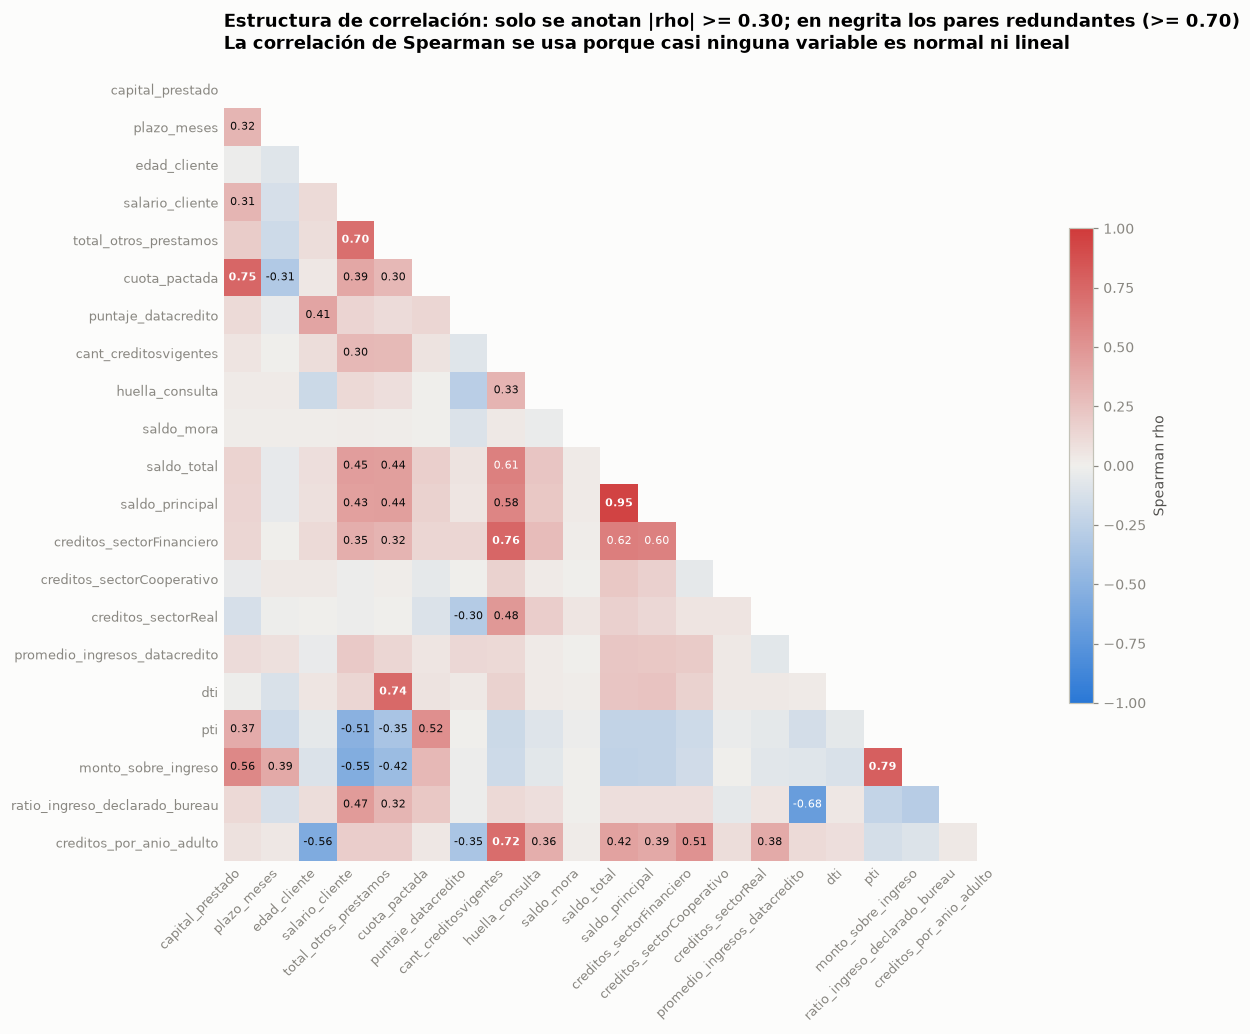

In [39]:
sin_fuga = [c for c in numericas if c != 'puntaje']
C = X[sin_fuga].corr('spearman')
mascara = np.triu(np.ones(C.shape, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9.5))
im = ax.imshow(np.where(mascara, np.nan, C.values), cmap=DIVERGENTE, vmin=-1, vmax=1)

for i in range(len(C)):
    for j in range(len(C)):
        if not mascara[i, j] and abs(C.values[i, j]) >= 0.3:
            ax.annotate(f'{C.values[i, j]:.2f}', (j, i), ha='center', va='center', fontsize=7.5,
                        color='#ffffff' if abs(C.values[i, j]) > 0.6 else TINTA,
                        fontweight='bold' if abs(C.values[i, j]) >= 0.7 else 'normal')

ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index, fontsize=8.5)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, label='Spearman rho', shrink=.6)
ax.set_title('Estructura de correlación: solo se anotan |rho| >= 0.30; en negrita los pares redundantes (>= 0.70)\n'
             'La correlación de Spearman se usa porque casi ninguna variable es normal ni lineal',
             pad=14)
fig.tight_layout()
plt.show()

In [40]:
pares = (C.where(~mascara).stack().rename('rho').reset_index()
          .rename(columns={'level_0': 'variable_a', 'level_1': 'variable_b'}))
pares['abs_rho'] = pares['rho'].abs()

fuerza_map = bivariado.set_index('variable')['fuerza']
redundantes = pares[pares['abs_rho'] >= 0.70].sort_values('abs_rho', ascending=False).copy()
redundantes['fuerza_a'] = redundantes['variable_a'].map(fuerza_map).round(3)
redundantes['fuerza_b'] = redundantes['variable_b'].map(fuerza_map).round(3)
redundantes['conservar'] = np.where(redundantes['fuerza_a'] >= redundantes['fuerza_b'],
                                    redundantes['variable_a'], redundantes['variable_b'])
redundantes['descartar'] = np.where(redundantes['fuerza_a'] >= redundantes['fuerza_b'],
                                    redundantes['variable_b'], redundantes['variable_a'])

print(redundantes[['variable_a', 'variable_b', 'rho', 'fuerza_a', 'fuerza_b', 'conservar', 'descartar']]
      .round(3).to_string(index=False))
print('\nCriterio: ante un par redundante se conserva la variable con mayor fuerza bivariada')
print('contra la mora y se descarta la otra, para no meter colinealidad al modelo.')

               variable_a            variable_b   rho  fuerza_a  fuerza_b                 conservar             descartar
          saldo_principal           saldo_total 0.946     0.025     0.040               saldo_total       saldo_principal
      monto_sobre_ingreso                   pti 0.793     0.079     0.022       monto_sobre_ingreso                   pti
creditos_sectorFinanciero cant_creditosvigentes 0.755     0.081     0.043 creditos_sectorFinanciero cant_creditosvigentes
            cuota_pactada      capital_prestado 0.751     0.040     0.114          capital_prestado         cuota_pactada
                      dti total_otros_prestamos 0.737     0.095     0.071                       dti total_otros_prestamos
 creditos_por_anio_adulto cant_creditosvigentes 0.716     0.079     0.043  creditos_por_anio_adulto cant_creditosvigentes
    total_otros_prestamos       salario_cliente 0.704     0.071     0.011     total_otros_prestamos       salario_cliente

Criterio: ante un par r

**Lectura:** hay siete pares redundantes por encima de 0.70. El más extremo es
`saldo_total` con `saldo_principal` (rho = 0.95): son prácticamente la misma columna y una de las dos
sobra. También se detectan las redundancias esperadas por construcción: `dti` con
`total_otros_prestamos`, `pti` con `monto_sobre_ingreso` y `creditos_por_anio_adulto` con
`cant_creditosvigentes`, esta última ya advertida en 2.6.

El criterio de la tabla es conservar en cada par la variable con más señal bivariada. Conviene
tomarla como punto de partida y no al pie de la letra, por las razones que se anotan bajo la tabla.

### 3.3.2 Score y consultas al buró combinados

**Pregunta:** las consultas al buró aportan información que el score no recoge ya?

Es la pregunta clave para saber si vale la pena usar ambas: si la huella solo reflejara lo que el
score ya sabe, el cruce mostraría filas planas.

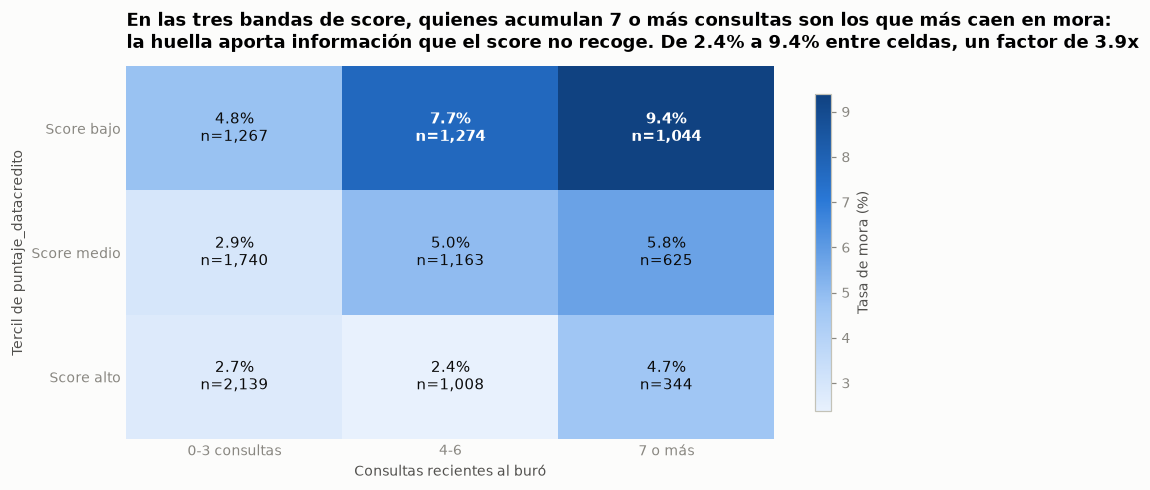

Chi-cuadrado de las 9 celdas contra la mora: 122.4, p = 1.68e-21
Rango de tasas: 2.38% a 9.39%  (base 4.75%)

La columna de 7 o más consultas es la peor en los tres terciles, aunque el paso 0-3 a 4-6
no es monótono en el tercil alto (2.71% a 2.38%):
huella_consulta      0-3 consultas   4-6  7 o más
puntaje_datacredito                              
Score bajo                    4.81  7.69     9.39
Score medio                   2.93  4.99     5.76
Score alto                    2.71  2.38     4.65


In [41]:
score_t = pd.qcut(X['puntaje_datacredito'], 3, labels=['Score bajo', 'Score medio', 'Score alto'])
huella_g = pd.cut(df['huella_consulta'], [-1, 3, 6, 30], labels=['0-3 consultas', '4-6', '7 o más'])

ax, tasa, n = mapa_calor_mora(score_t, huella_g,
    'En las tres bandas de score, quienes acumulan 7 o más consultas son los que más caen en mora:\n'
    'la huella aporta información que el score no recoge. De 2.4% a 9.4% entre celdas, un factor de 3.9x',
    'Consultas recientes al buró', 'Tercil de puntaje_datacredito', figsize=(9.5, 4.4))
plt.show()

tabla = pd.crosstab(score_t, huella_g, values=mora, aggfunc='mean').mul(100)
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(score_t.astype(str) + ' | ' + huella_g.astype(str), mora))
print(f'Chi-cuadrado de las 9 celdas contra la mora: {chi2:.1f}, p = {p:.2e}')
print(f'Rango de tasas: {tabla.values.min():.2f}% a {tabla.values.max():.2f}%  (base {BASE:.2f}%)')
print('\nLa columna de 7 o más consultas es la peor en los tres terciles, aunque el paso 0-3 a 4-6')
print('no es monótono en el tercil alto (2.71% a 2.38%):')
print(tabla.round(2).to_string())

**Lectura:** las filas no son planas, así que la huella aporta información propia. En los tres
terciles de score, el grupo con 7 o más consultas es el de mayor mora, y el efecto es sustancial: un
cliente de score bajo pasa de 4.8% a 9.4% según su huella. Combinadas, las dos variables separan de
2.4% a 9.4%, un factor de 3.9, contra el 3.3 que lograba el score solo.

El único tramo que no ordena es el paso de 0-3 a 4-6 consultas en el tercil alto (2.71% a 2.38%),
diferencia pequeña y dentro del ruido esperable.

### 3.3.3 Tipo laboral según la edad

**Pregunta:** ¿¿El mayor riesgo del trabajador independiente es parejo a todas las edades?

En la tabla bivariada `tipo_laboral` aparecía como una de las variables más débiles (V de Cramér
0.027). La sospecha es que el promedio esconde un efecto concentrado en un subgrupo.

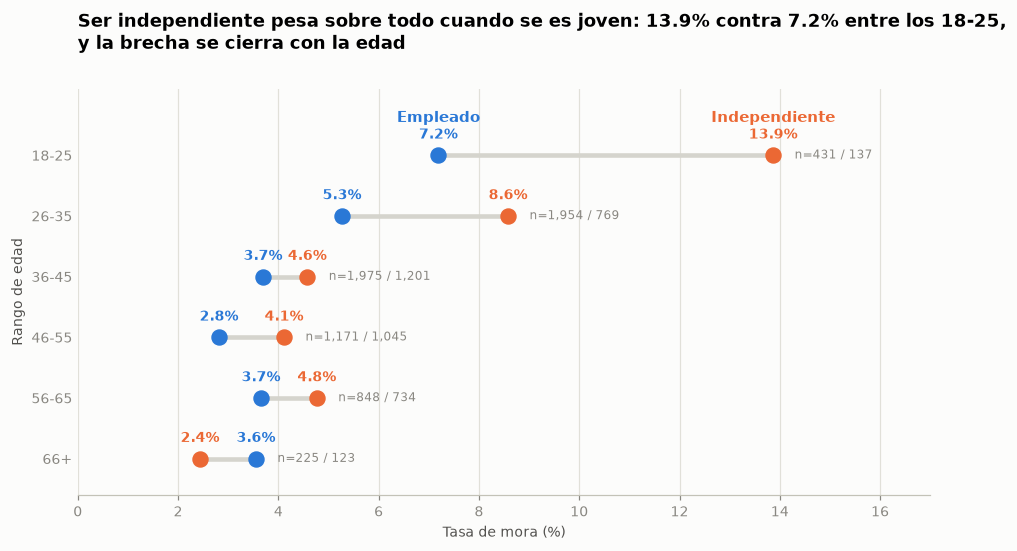

            Empleado_%  Independiente_%  brecha_pp  n_emp  n_ind
rango_edad                                                      
18-25             7.19            13.87       6.68    431    137
26-35             5.27             8.58       3.31   1954    769
36-45             3.70             4.58       0.88   1975   1201
46-55             2.82             4.11       1.30   1171   1045
56-65             3.66             4.77       1.11    848    734
66+               3.56             2.44      -1.12    225    123

Efecto de tipo_laboral en menores de 36: chi2 = 14.4, p = 0.0002
Efecto de tipo_laboral en 36 o más:     chi2 = 3.0, p = 0.0846


In [42]:
t = (mora.groupby([df['rango_edad'], df['tipo_laboral']], observed=True)
         .agg(n='size', casos='sum').reset_index())
t['tasa'] = t['casos'] / t['n'] * 100
pivote = t.pivot(index='rango_edad', columns='tipo_laboral', values='tasa')
enes = t.pivot(index='rango_edad', columns='tipo_laboral', values='n')

fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(pivote))
ax.hlines(y, pivote['Empleado'], pivote['Independiente'], color='#d5d4cd', lw=3, zorder=1)
ax.scatter(pivote['Empleado'], y, s=95, color=AZUL, zorder=2)
ax.scatter(pivote['Independiente'], y, s=95, color=NARANJA, zorder=2)

for yi, banda in enumerate(pivote.index):
    e, i = pivote.loc[banda, 'Empleado'], pivote.loc[banda, 'Independiente']
    ax.annotate(f"{e:.1f}%", (e, yi), xytext=(0, 11), textcoords='offset points', ha='center',
                fontsize=9, color=AZUL, fontweight='bold')
    ax.annotate(f"{i:.1f}%", (i, yi), xytext=(0, 11), textcoords='offset points', ha='center',
                fontsize=9, color=NARANJA, fontweight='bold')
    ax.annotate(f"n={enes.loc[banda,'Empleado']:,} / {enes.loc[banda,'Independiente']:,}",
                (max(e, i), yi), xytext=(14, 0), textcoords='offset points', va='center',
                fontsize=8, color=GRIS)

ax.annotate('Empleado', (pivote['Empleado'].iloc[0], -0.55), ha='center', fontsize=10,
            color=AZUL, fontweight='bold')
ax.annotate('Independiente', (pivote['Independiente'].iloc[0], -0.55), ha='center', fontsize=10,
            color=NARANJA, fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(pivote.index); ax.invert_yaxis()
ax.set_xlabel('Tasa de mora (%)'); ax.set_ylabel('Rango de edad')
ax.set_xlim(0, 17); ax.set_ylim(len(pivote) - 0.4, -1.1)
ax.grid(axis='x'); ax.set_axisbelow(True); ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.set_title('Ser independiente pesa sobre todo cuando se es joven: 13.9% contra 7.2% entre los 18-25,\n'
             'y la brecha se cierra con la edad', pad=26)
plt.show()

print(pd.DataFrame({'Empleado_%': pivote['Empleado'].round(2), 'Independiente_%': pivote['Independiente'].round(2),
                    'brecha_pp': (pivote['Independiente'] - pivote['Empleado']).round(2),
                    'n_emp': enes['Empleado'], 'n_ind': enes['Independiente']}).to_string())
jovenes = df['rango_edad'].isin(['18-25', '26-35'])
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df['tipo_laboral'][jovenes], mora[jovenes]))
chi2b, pb, _, _ = stats.chi2_contingency(pd.crosstab(df['tipo_laboral'][~jovenes], mora[~jovenes]))
print(f'\nEfecto de tipo_laboral en menores de 36: chi2 = {chi2:.1f}, p = {p:.4f}')
print(f'Efecto de tipo_laboral en 36 o más:     chi2 = {chi2b:.1f}, p = {pb:.4f}')

**Lectura:** la sospecha se confirma y explica por que la variable parecía débil. Entre los menores de
36 años el tipo laboral si importa (chi-cuadrado 14.4, p = 0.0002); de los 36 en adelante deja de
importar (p = 0.085). La brecha va de 6.7 puntos porcentuales en los más jovenes a prácticamente cero
en la madurez, e incluso se invierte después de los 66, aunque ese tramo tiene apenas 123
independientes y no soporta lectura.

Es un caso de manual: promediar sobre toda la cartera diluyo un efecto real hasta hacerlo invisible.
Al modelar conviene incluir la interacción entre edad y tipo laboral, no solo los dos efectos sueltos.

### 3.3.4 Monto y plazo combinados

**Pregunta:** ¿Dónde se concentra el riesgo dentro de la estructura del producto?

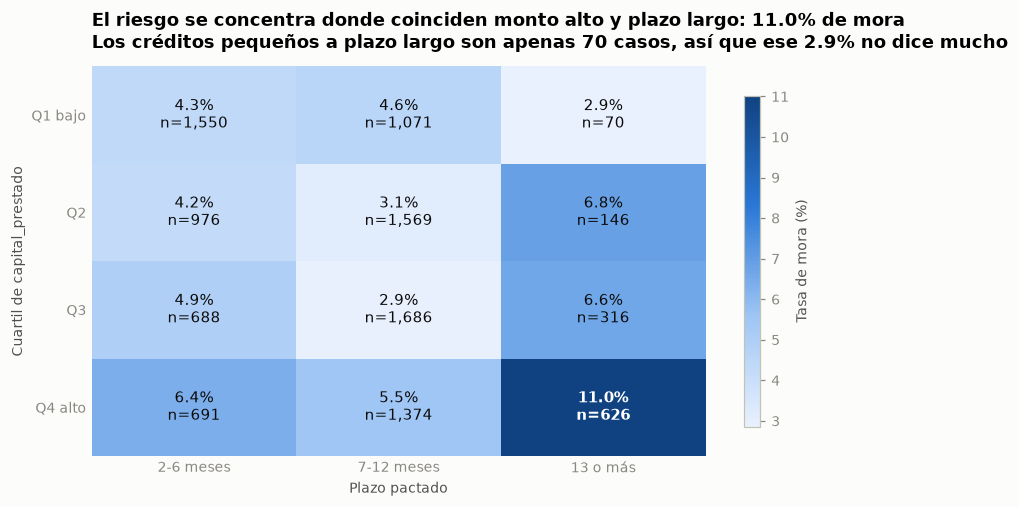

Chi-cuadrado de las 12 celdas: 88.1, p = 3.99e-14

Tasas (%):
plazo_meses       2-6 meses  7-12 meses  13 o más
capital_prestado                                 
Q1 bajo                4.32        4.58      2.86
Q2                     4.20        3.12      6.85
Q3                     4.94        2.91      6.65
Q4 alto                6.37        5.53     11.02

Tamaños de celda:
plazo_meses       2-6 meses  7-12 meses  13 o más
capital_prestado                                 
Q1 bajo                1550        1071        70
Q2                      976        1569       146
Q3                      688        1686       316
Q4 alto                 691        1374       626


In [43]:
capital_q = pd.qcut(df['capital_prestado'], 4, labels=['Q1 bajo', 'Q2', 'Q3', 'Q4 alto'])
plazo_g = pd.cut(df['plazo_meses'], [0, 6, 12, 90], labels=['2-6 meses', '7-12 meses', '13 o más'])

ax, tasa, n = mapa_calor_mora(capital_q, plazo_g,
    'El riesgo se concentra donde coinciden monto alto y plazo largo: 11.0% de mora\n'
    'Los créditos pequeños a plazo largo son apenas 70 casos, así que ese 2.9% no dice mucho',
    'Plazo pactado', 'Cuartil de capital_prestado', figsize=(9, 4.6))
plt.show()

chi2, p, _, _ = stats.chi2_contingency(
    pd.crosstab(capital_q.astype(str) + ' | ' + plazo_g.astype(str), mora))
print(f'Chi-cuadrado de las 12 celdas: {chi2:.1f}, p = {p:.2e}')
print(f'\nTasas (%):\n{tasa.round(2).to_string()}')
print(f'\nTamaños de celda:\n{n.to_string()}')

**Lectura:** el riesgo se concentra en una esquina concreta: montos del cuartil alto a 13 meses o más
llegan al 11.0% de mora sobre 626 créditos, muestra suficiente para tomarlo en serio. Es el único
cruce de esta sección que apunta a una **palanca directa de política**, porque tanto el monto como el
plazo los fija la entidad.

La celda opuesta (monto bajo y plazo largo, 2.9%) tiene solo 70 créditos y no admite conclusión. Vale
la advertencia de exposición temporal de 3.2.4: la columna de plazo largo esta parcialmente inflada.

### 3.3.5 Las dos señales de ingreso del buró

**Pregunta:** ¿¿Sobredeclarar el ingreso y venir con ingresos a la baja son riesgos que se suman?

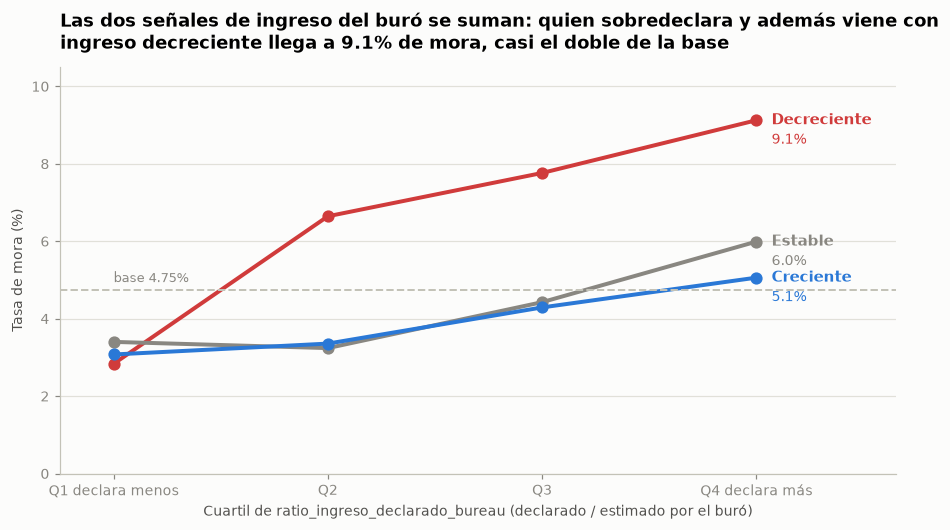

tendencia_ingresos              Decreciente  Estable  Creciente
ratio_ingreso_declarado_bureau                                 
Q1 declara menos                       2.84     3.40       3.08
Q2                                     6.65     3.24       3.36
Q3                                     7.76     4.43       4.29
Q4 declara más                         9.13     5.99       5.06

Tamaños de celda:
tendencia_ingresos              Decreciente  Estable  Creciente
ratio_ingreso_declarado_bureau                                 
Q1 declara menos                        388      147       1398
Q2                                      316      216       1400
Q3                                      322      384       1235
Q4 declara más                          263      434       1245


In [44]:
ratio_q = pd.qcut(X['ratio_ingreso_declarado_bureau'], 4,
                  labels=['Q1 declara menos', 'Q2', 'Q3', 'Q4 declara más'])
t = (mora.groupby([ratio_q, df['tendencia_ingresos']], observed=True)
         .agg(n='size', casos='sum').reset_index())
t['tasa'] = t['casos'] / t['n'] * 100
pivote = t.pivot(index='ratio_ingreso_declarado_bureau', columns='tendencia_ingresos', values='tasa')

fig, ax = plt.subplots(figsize=(9.8, 4.8))
colores = {'Decreciente': CRITICO, 'Estable': GRIS, 'Creciente': AZUL}
x = np.arange(len(pivote))

for col in ['Decreciente', 'Estable', 'Creciente']:
    ax.plot(x, pivote[col], color=colores[col], lw=2.6, marker='o', ms=7)
    ax.annotate(col, (x[-1], pivote[col].iloc[-1]), xytext=(10, 0), textcoords='offset points',
                va='center', fontsize=10, fontweight='bold', color=colores[col])
    ax.annotate(f'{pivote[col].iloc[-1]:.1f}%', (x[-1], pivote[col].iloc[-1]), xytext=(10, -13),
                textcoords='offset points', va='center', fontsize=9, color=colores[col])

ax.axhline(BASE, color='#c3c2b7', lw=1.3, ls='--')
ax.annotate(f'base {BASE:.2f}%', (0, BASE), xytext=(0, 5), textcoords='offset points',
            fontsize=8.5, color=GRIS)
ax.set_xticks(x); ax.set_xticklabels(pivote.index)
ax.set_xlim(-.25, len(x) - .35); ax.set_ylim(0, 10.5)
ax.set_xlabel('Cuartil de ratio_ingreso_declarado_bureau (declarado / estimado por el buró)')
ax.set_ylabel('Tasa de mora (%)'); ax.grid(axis='y'); ax.set_axisbelow(True)
ax.set_title('Las dos señales de ingreso del buró se suman: quien sobredeclara y además viene con\n'
             'ingreso decreciente llega a 9.1% de mora, casi el doble de la base', pad=12)
plt.show()

print(pivote.round(2).to_string())
print('\nTamaños de celda:')
print(t.pivot(index='ratio_ingreso_declarado_bureau', columns='tendencia_ingresos', values='n').to_string())

**Lectura:** se suman. Dentro de cada nivel de tendencia la mora crece con el cuartil de
sobredeclaración, y la línea de ingreso decreciente esta siempre por encima de las otras dos. El
extremo (declara mucho más de lo que el buró le estima, y con ingresos a la baja) llega a 9.1% sobre
263 créditos, casi el doble de la base, contra 2.8% en la esquina opuesta.

Es coherente con la lectura de 3.2.2: lo que discrimina no es cuanto dice ganar el cliente, sino
**cuanto se aparta lo que dice de lo que el buró observa**.

### 3.3.6 Vista conjunta de las variables con más señal

**Pregunta:** ¿Existe alguna región del espacio de variables donde la mora se concentre lo bastante
como para separarla con reglas simples?

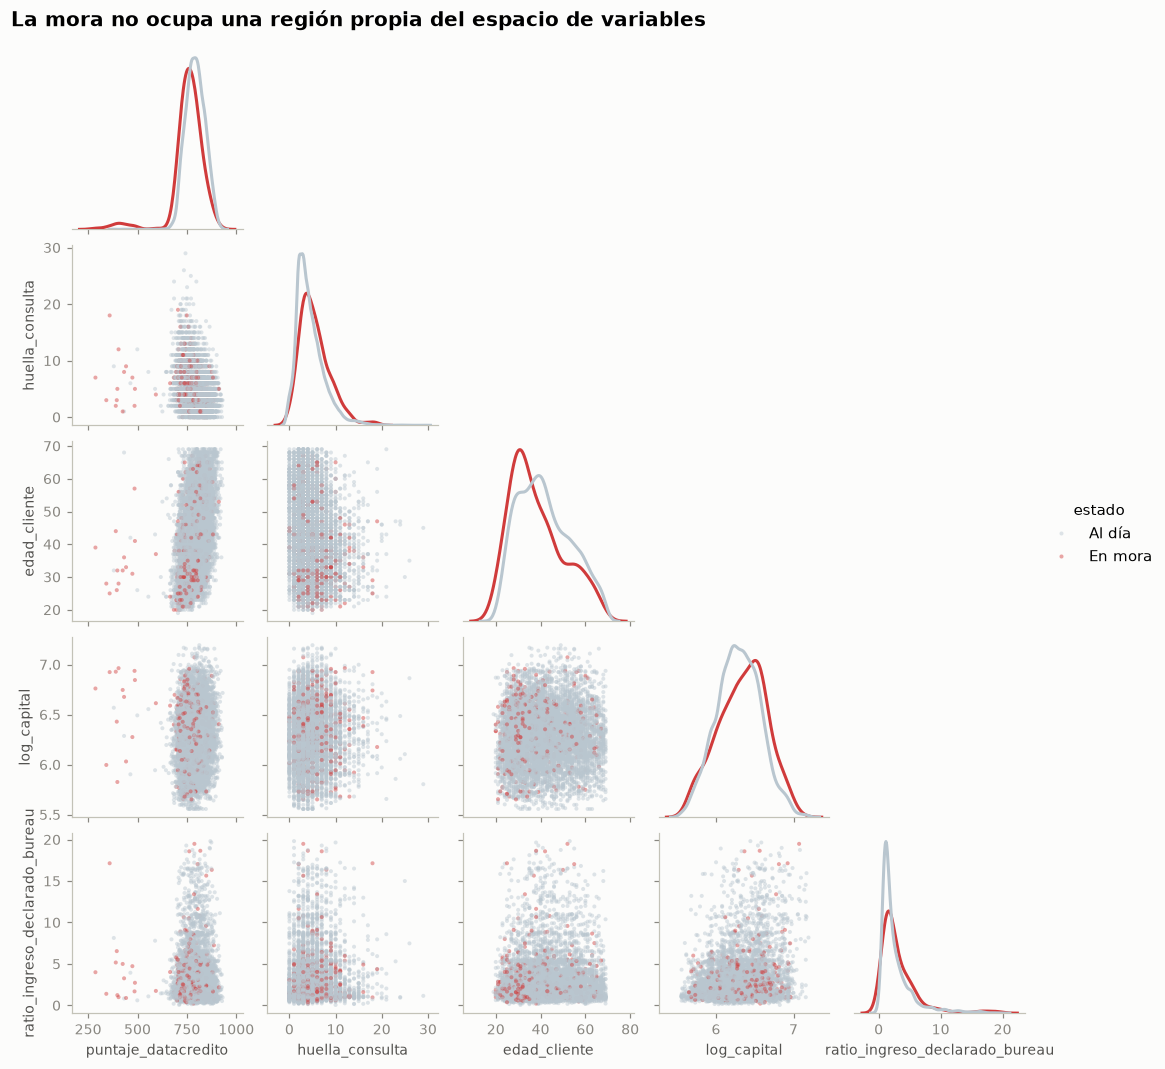

n graficado = 7,573 (se excluyen filas con nulos y ratios > 20 para que la escala sea legible)
De ellos, 321 están en mora (4.24%).

La mora se dibuja encima de los pagos al día. Aun así no aparece ninguna frontera limpia:
las nubes se solapan en los diez paneles. Las densidades de la diagonal muestran corrimientos
reales pero pequeños, coherentes con los tamaños de efecto de 3.2: el problema no se resuelve
con una regla de corte sobre una variable, necesita un modelo que combine varias.


In [45]:
variables_pp = ['puntaje_datacredito', 'huella_consulta', 'edad_cliente',
                'log_capital', 'ratio_ingreso_declarado_bureau']
datos_pp = X.assign(log_capital=np.log10(X['capital_prestado']),
                    estado=np.where(mora, 'En mora', 'Al día'))[variables_pp + ['estado']].dropna()
datos_pp = datos_pp[datos_pp['ratio_ingreso_declarado_bureau'] < 20]

g = sns.pairplot(datos_pp, vars=variables_pp, hue='estado', hue_order=['Al día', 'En mora'],
                 palette={'Al día': '#b9c6cf', 'En mora': CRITICO}, height=1.9, corner=True,
                 diag_kind='kde', plot_kws=dict(s=7, alpha=.45, edgecolor='none'),
                 diag_kws=dict(fill=False, lw=2, common_norm=False, warn_singular=False))
g.figure.suptitle('La mora no ocupa una región propia del espacio de variables', y=1.02,
                  x=0.01, ha='left', fontsize=13, fontweight='bold')
plt.show()

print(f'n graficado = {len(datos_pp):,} (se excluyen filas con nulos y ratios > 20 para que la escala sea legible)')
print(f'De ellos, {int((datos_pp["estado"] == "En mora").sum()):,} están en mora '
      f'({(datos_pp["estado"] == "En mora").mean():.2%}).')
print('\nLa mora se dibuja encima de los pagos al día. Aun así no aparece ninguna frontera limpia:')
print('las nubes se solapan en los diez paneles. Las densidades de la diagonal muestran corrimientos')
print('reales pero pequeños, coherentes con los tamaños de efecto de 3.2: el problema no se resuelve')
print('con una regla de corte sobre una variable, necesita un modelo que combine varias.')

**Lectura:** no existe. Las nubes se solapan en los diez paneles y las densidades de la diagonal
muestran corrimientos reales pero pequeños, exactamente del tamaño que anticipaban los efectos de
3.2.1. Ninguna frontera sobre una o dos variables separa las clases.

Es una conclusión útil y no un resultado negativo: confirma que el problema exige un modelo que
combine varias señales débiles, y que la ganancia va a venir de la combinación (como muestra 3.3.2),
no de encontrar la variable mágica.

### 3.3.7 Segmentos de riesgo

**Pregunta:** ¿Cuánto se puede separar el riesgo combinando las tres variables con más señal?

Se cruzan tercil de score, banda de consultas y rango de edad, y se conservan solo los segmentos con
al menos 100 créditos para que las tasas sean interpretables.

In [46]:
segmento = (score_t.astype(str) + '  /  ' + huella_g.astype(str) + '  /  ' + df['rango_edad'].astype(str))
seg = tasa_mora(segmento.where(segmento.notna()))
seg = seg[seg['n'] >= 100].sort_values('tasa', ascending=False)
seg['lift'] = (seg['tasa'] / BASE).round(2)

print(f'Segmentos con al menos 100 créditos, ordenados por tasa de mora ({len(seg)} de '
      f'{segmento.nunique()} combinaciones posibles superan ese umbral)\n')
print('--- Los 5 más riesgosos ---')
print(seg.head(5)[['n', 'casos', 'tasa', 'lo', 'hi', 'lift']].round(2).to_string())
print('\n--- Los 5 menos riesgosos ---')
print(seg.tail(5)[['n', 'casos', 'tasa', 'lo', 'hi', 'lift']].round(2).to_string())
print(f'\nBase de la cartera: {BASE:.2f}%. El segmento más riesgoso multiplica la base por '
      f'{seg["lift"].iloc[0]:.1f} y el menos riesgoso la divide por {1/seg["lift"].iloc[-1]:.1f}.')
print('Los intervalos de confianza de los extremos no se solapan, así que la separación no es ruido.')

Segmentos con al menos 100 créditos, ordenados por tasa de mora (35 de 64 combinaciones posibles superan ese umbral)

--- Los 5 más riesgosos ---
                                     n  casos   tasa    lo     hi  lift
Score bajo  /  4-6  /  18-25       162     18  11.11  7.14  16.88  2.34
Score medio  /  7 o más  /  26-35  179     19  10.61  6.90  15.98  2.24
Score bajo  /  7 o más  /  18-25   123     13  10.57  6.28  17.25  2.23
Score bajo  /  7 o más  /  36-45   315     32  10.16  7.29  13.99  2.14
Score bajo  /  7 o más  /  26-35   415     40   9.64  7.16  12.86  2.03

--- Los 5 menos riesgosos ---
                                           n  casos  tasa    lo    hi  lift
Score medio  /  0-3 consultas  /  56-65  285      6  2.11  0.97  4.52  0.44
Score alto  /  0-3 consultas  /  66+     143      3  2.10  0.72  5.99  0.44
Score alto  /  0-3 consultas  /  26-35   235      4  1.70  0.66  4.29  0.36
Score alto  /  4-6  /  26-35             126      2  1.59  0.44  5.60  0.33
Score medio

**Lectura:** el segmento más riesgoso (score bajo, 4-6 consultas, 18-25 años) llega a 11.1% de mora y
el menos riesgoso (score medio, 0-3 consultas, 36-45 años) baja a 1.4%. Son 7.7 veces de diferencia,
y los intervalos de confianza de ambos extremos no se solapan, así que la separación no es ruido.

Con solo tres variables y sin modelo se logra un ordenamiento útil. Eso fija una referencia razonable
contra la cual medir cualquier modelo de la siguiente etapa: si no supera comodamente este corte
manual, no esta aportando.

## 3.4 Transformaciones recomendadas

**Pregunta:** ¿Qué hay que hacerle a cada variable antes de modelar?

El entregable pide identificar las transformaciones aplicables. La tabla se construye a partir de las
estadísticas ya medidas y no de criterios a mano: la asimetría y la relación máximo/p99 de 3.1,
la fuerza bivariada de 3.2 y las redundancias de 3.3.

In [47]:
descartar = set(redundantes['descartar'])
plan = []
for c in df.columns:
    if c == 'puntaje':
        plan.append((c, 'Excluir del modelo', 'Fuga: se calcula después de conocer el pago (ver 2.3)'))
    elif c == 'Pago_atiempo':
        plan.append((c, 'Variable objetivo', f'Clase positiva rara ({BASE:.2f}%): usar class_weight o remuestreo'))
    elif c == 'fecha_prestamo':
        plan.append((c, 'No usar directa', 'Solo como cosecha (mes_prestamo) para controlar censura'))
    elif c == 'mes_prestamo':
        plan.append((c, 'Control de cosecha', 'Entra como control, no como predictor de negocio'))
    elif c in descartar:
        pareja = redundantes.loc[redundantes['descartar'] == c, 'conservar'].iloc[0]
        rho_p = redundantes.loc[redundantes['descartar'] == c, 'rho'].iloc[0]
        plan.append((c, 'Descartar por redundancia', f'rho = {rho_p:.2f} con {pareja}, que tiene más señal'))
    elif str(df[c].dtype) == 'bool':
        plan.append((c, 'Ya binaria', 'Usar tal cual'))
    elif str(df[c].dtype) == 'category':
        orden = 'ordinal (tiene orden natural)' if df[c].cat.ordered else 'one-hot'
        plan.append((c, f'Codificar {orden}', f'{df[c].nunique()} niveles'))
    else:
        s = X[c].dropna()
        a = s.skew()
        cola = s.max() / s.quantile(.99) if s.quantile(.99) > 0 else np.inf
        if (s == s.mode().iloc[0]).mean() > 0.90:
            plan.append((c, 'Binarizar (> 0)', f'{(s == s.mode().iloc[0]).mean():.1%} de los valores son iguales'))
        elif a > 2 and cola > 10:
            plan.append((c, 'Winsorizar p99 y luego log1p',
                         f'asimetría {a:.1f} y el máximo es {cola:.0f}x el p99'))
        elif a > 2:
            plan.append((c, 'log1p', f'asimetría {a:.1f} baja a {np.log1p(s[s>=0]).skew():.1f}'))
        elif abs(a) <= 2:
            plan.append((c, 'Escalar (sin transformar)', f'asimetría {a:.1f}, forma manejable'))

transformaciones = pd.DataFrame(plan, columns=['variable', 'transformación', 'motivo'])
imputables = [c for c in df.columns if df[c].isna().any()]
transformaciones['nulos'] = transformaciones['variable'].map(df.isna().sum())
transformaciones['imputación'] = np.where(
    transformaciones['variable'].isin(imputables),
    'Marcar con indicador de ausencia + imputar por mediana o categoría "sin dato"', '')

print(transformaciones.to_string(index=False))
print('\nAdvertencias sobre la columna "descartar por redundancia":')
print('- La regla es por pares y codiciosa, así que puede encadenarse: salario_cliente se descarta')
print('  frente a total_otros_prestamos, que a su vez se descarta frente a dti. La selección final')
print('  debe hacerse de forma iterativa en la etapa de modelado, no leyendo está columna literalmente.')
print('- Varias variables descartadas como predictoras siguen siendo necesarias como insumo: salario_cliente')
print('  alimenta dti, pti y monto_sobre_ingreso, y cuota_pactada alimenta pti. Descartar no es eliminar.')

                      variable               transformación                                                        motivo  nulos                                                                    imputación
                  tipo_credito            Codificar one-hot                                                     4 niveles      0                                                                              
                fecha_prestamo              No usar directa       Solo como cosecha (mes_prestamo) para controlar censura      0                                                                              
              capital_prestado                        log1p                                      asimetría 3.7 baja a 0.1      0                                                                              
                   plazo_meses                        log1p                                      asimetría 2.5 baja a 0.6      0                                            

Para verificar que la transformación propuesta hace lo que promete, se aplica a dos casos extremos.

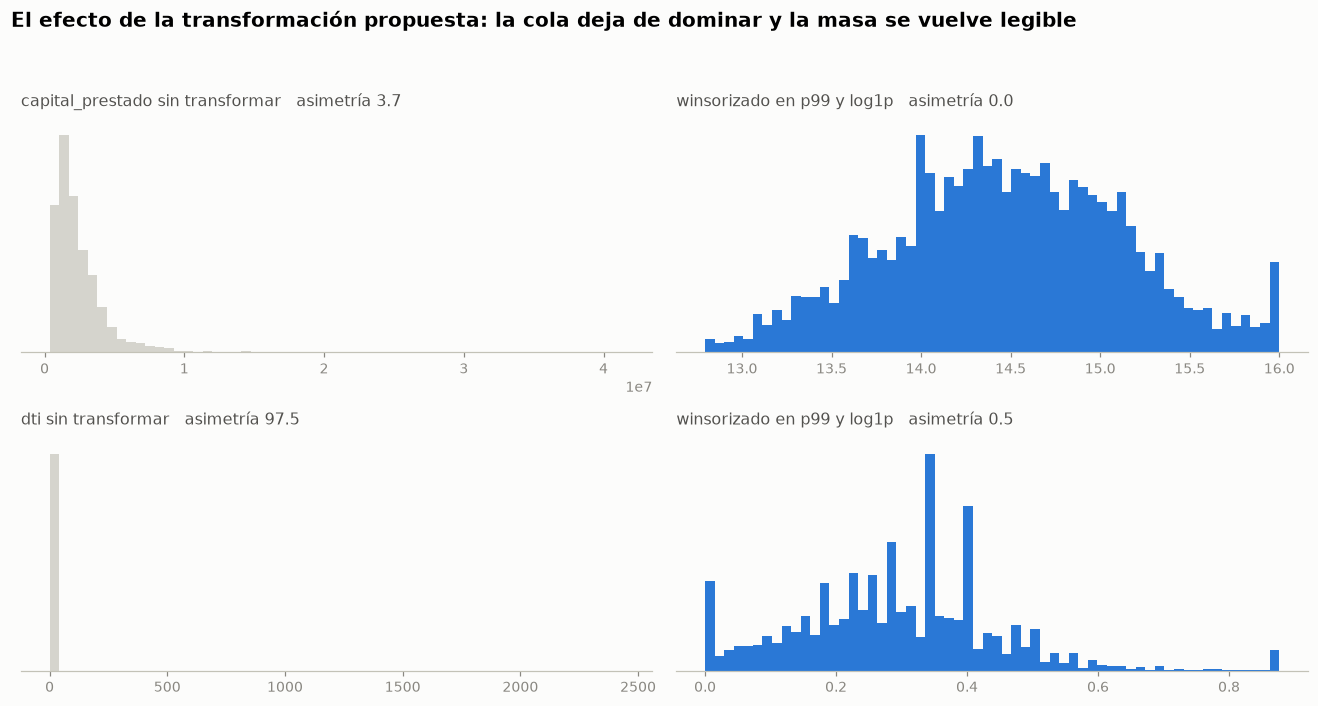

Asimetría antes y después:
  capital_prestado                     3.72  ->    0.03
  total_otros_prestamos               38.46  ->   -3.77
  salario_cliente                     19.48  ->    0.42
  cuota_pactada                        3.79  ->    0.32
  dti                                 97.48  ->    0.52
  pti                                 96.70  ->    1.84
  monto_sobre_ingreso                 95.30  ->    0.86
  ratio_ingreso_declarado_bureau      19.63  ->    2.11


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))

for fila, col in zip(axes, ['capital_prestado', 'dti']):
    s = X[col].dropna()
    fila[0].hist(s, bins=60, color='#d5d4cd', edgecolor='none')
    fila[0].set_title(f'{col} sin transformar   asimetría {s.skew():.1f}', fontsize=10.5,
                      color=TINTA2, fontweight='normal')
    t = np.log1p(s.clip(upper=s.quantile(.99)))
    fila[1].hist(t, bins=60, color=AZUL, edgecolor='none')
    fila[1].set_title(f'winsorizado en p99 y log1p   asimetría {t.skew():.1f}', fontsize=10.5,
                      color=TINTA2, fontweight='normal')
    for ax in fila:
        ax.set_yticks([]); ax.spines['left'].set_visible(False)
        ax.grid(axis='y'); ax.set_axisbelow(True)

fig.suptitle('El efecto de la transformación propuesta: la cola deja de dominar y la masa se vuelve legible',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print('Asimetría antes y después:')
for col in ['capital_prestado', 'total_otros_prestamos', 'salario_cliente', 'cuota_pactada',
            'dti', 'pti', 'monto_sobre_ingreso', 'ratio_ingreso_declarado_bureau']:
    s = X[col].dropna()
    t = np.log1p(s.clip(upper=s.quantile(.99)))
    print(f'  {col:32s} {s.skew():8.2f}  ->  {t.skew():6.2f}')

**Lectura:** `dti` pasa de asimetría 97.5, donde el histograma es una sola barra, a 0.5 con una forma
perfectamente utilizable. `capital_prestado` pasa de 3.7 a 0.0. El recorte en el percentil 99 hace el
trabajo pesado y el logaritmo termina de simetrizar.

Una salvedad: en las variables con mucha masa en cero (`total_otros_prestamos`, `saldo_total`) el
logaritmo sobrecorrige y las deja sesgadas a la izquierda. Para esas conviene tratar el cero aparte,
con un indicador booleano más el logaritmo del resto.

## 3.5 Síntesis y limitaciones

### Lo que muestran los datos

**1. El buró predice; lo que el cliente declara sobre su plata, no.** Es el hallazgo central. Las
cuatro variables más asociadas a la mora vienen del buró o del contraste con el buró:
`puntaje_datacredito` (AUC 0.376), `huella_consulta` (0.598), `ratio_ingreso_declarado_bureau` (0.574)
y `promedio_ingresos_datacredito` (0.427). En el fondo de la tabla quedan `salario_cliente`
(AUC 0.505), `pti` (0.511) y `cuota_supera_salario` (V de Cramér 0.000). La capacidad de pago
declarada, que es lo que tradicionalmente sostiene la decisión de crédito, no esta separando buenos
de malos en esta cartera.

**2. Las consultas al buró son la señal más limpia, y el score no la recoge.** De 0-1 consultas a 11
o más la mora va de 3.6% a 10.1%, y el efecto se mantiene dentro de las tres bandas de score.
Cruzando ambas variables la mora va de 2.4% a 9.4%.

**3. La discrepancia de ingresos vale más que el ingreso.** Quien declara mucho más de lo que el buró
le estima, y además viene con ingresos a la baja, llega a 9.1% de mora contra 2.8% en la esquina
opuesta.

**4. El riesgo del independiente es un fenómeno de los jovenes.** La variable parecía irrelevante en
promedio (V de Cramér 0.027), pero entre los menores de 36 el efecto es real (p = 0.0002) y
desaparece después (p = 0.085). Debe modelarse como interacción con la edad, no como efecto suelto.

**5. Monto alto con plazo largo es la única palanca directa de política.** El cuartil superior de
`capital_prestado` a 13 meses o más marca 11.0% de mora sobre 626 créditos.

**6. Con tres variables y sin modelo el riesgo ya se separa 7.7 veces.** De 1.4% a 11.1% entre
segmentos de más de 100 créditos, con intervalos que no se solapan. Es la referencia minima que
deberá superar cualquier modelo de la siguiente etapa.

### Limitaciones

**Censura por cosecha.** Es la limitación más sería. Entre las cosechas maduras la mora observada cae
de forma significativa con el mes de desembolso (Spearman rho = -0.90, p = 0.0001) por el simple
hecho de que los créditos recientes han tenido menos tiempo de deteriorarse. El 4.75% es un **piso**,
no la tasa final de la cartera, y toda comparación entre grupos con composición temporal distinta
arrastra parte de este sesgo. Corregirlo exige la fecha de la mora, que no esta en la base.

**Exposición desigual por plazo.** Por la misma razón, el gradiente de mora por plazo mezcla riesgo
real con tiempo de exposición. El hallazgo se reporta con esa reserva explicita.

**Fuga en `puntaje`.** Documentada en 2.3 y excluida de todo el análisis: el 87% de los créditos
comparte el valor máximo y ninguno de ellos cayó en mora.

**`tiene_mora_bureau` puede arrastrar fuga de temporalidad.** Muestra 36.4% de mora contra 4.6%, pero
sobre apenas 55 créditos, y no esta verificado si `saldo_mora` se observa en el momento de la
originación o después. Si es lo segundo, la variable no es utilizable como predictora. **Debe
confirmarse con el negocio antes de modelar.**

**Segmentos demasiado pequeños para concluir.** `tipo_credito = Otro` (24 créditos, intervalo del
21.2% al 57.3%), `cuota_supera_salario` (11 créditos) y las cosechas de 2026 (11 a 127 créditos por
mes). Se reportan con su n y su intervalo, y no se extrae conclusión de ellos.

**Ausencias no aleatorias.** El bloque de ingresos del buró falta en el 27% de los casos, y en las
ocho variables con nulos el grupo sin dato siempre cae más en mora, aunque solo tres alcanzan
significancia individual. Al imputar hay que conservar un indicador de ausencia por variable.

**Escala dudosa de los saldos de buró.** `saldo_total` tiene mediana de 16 178, cifra implausiblemente
baja para pesos colombianos; es posible que estén reportados en miles. No se construyó ningun
indicador que mezcle estos saldos con montos en pesos, y **conviene confirmar la unidad con el
proveedor del dato.**

**Sin diccionario de datos.** Toda la semántica se infirió del negocio y de la distribución observada,
como ya se advirtió en 2.1.